In [13]:
# ═══════════════════════════════════════════════════════════
# КЛІТИНКА 1 — Імпорти
# ═══════════════════════════════════════════════════════════
import sys, os, gc, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (accuracy_score, mean_squared_error,
                             mean_absolute_error, silhouette_score)
from sklearn.manifold import TSNE
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('.'))
from data_loader import DataLoader
from semantic_analyzer import SemanticAnalyzer

print("Імпорт завершено.")

Імпорт завершено.


In [21]:
def semantic_search(query_vector, matrix, k=100):
    scores = matrix @ query_vector
    top_indices = np.argpartition(scores, -k)[-k:]
    top_indices = top_indices[np.argsort(scores[top_indices])[::-1]]
    return {'indices': top_indices, 'scores': scores[top_indices]}

In [14]:
# ═══════════════════════════════════════════════════════════
# КЛІТИНКА 2 — Завантаження корпусу і матриці
# ═══════════════════════════════════════════════════════════
CORPUS_PATH = 'bible_kjv.txt'
CACHE_PATH  = 'matrix_cache.npy'

loader = DataLoader(gospels_only=True)
loader.load_file(CORPUS_PATH)
verses = loader.flatten_verses()
texts  = [v['text'] for v in verses]

matrix = np.array(np.load(CACHE_PATH, mmap_mode='r'), dtype=np.float32)

book_labels_int = {'Matthew': 0, 'Mark': 1, 'Luke': 2, 'John': 3}
book_colors     = {'Matthew': '#e74c3c', 'Mark': '#3498db',
                   'Luke': '#2ecc71',    'John': '#f39c12'}

print(f"Корпус: {len(verses)} віршів")
print(f"Книги:  {list(loader.parsed_corpus.keys())}")
print(f"Матриця ембеддингів: {matrix.shape} | {matrix.nbytes/1024/1024:.2f} МБ")

Корпус: 3779 віршів
Книги:  ['Matthew', 'Mark', 'Luke', 'John']
Матриця ембеддингів: (3779, 768) | 11.07 МБ


In [15]:
# ═══════════════════════════════════════════════════════════
# КЛІТИНКА 3 — Визначення запитів і ground truth
# ═══════════════════════════════════════════════════════════
QUERIES = [
    {
        'text':     'love your enemies',
        'keywords': ['love', 'enemy', 'enemies', 'hate', 'neighbour', 'neighbor'],
        'label':    'love your enemies',
        'short':    'Q1',
    },
    {
        'text':     'the kingdom of heaven',
        'keywords': ['kingdom', 'heaven', 'kingdom of heaven', 'kingdom of god'],
        'label':    'the kingdom of heaven',
        'short':    'Q2',
    },
    {
        'text':     'forgiveness of sins',
        'keywords': ['forgiv', 'sin', 'repent', 'remission', 'transgress', 'iniquity'],
        'label':    'forgiveness of sins',
        'short':    'Q3',
    },
]

def is_relevant(verse_text, keywords):
    t = verse_text.lower()
    return any(kw.lower() in t for kw in keywords)

for q in QUERIES:
    rel = np.array([1 if is_relevant(v['text'], q['keywords']) else 0
                    for v in verses], dtype=np.int32)
    q['relevance']  = rel
    q['n_relevant'] = int(rel.sum())
    print(f"[{q['label']:30s}]  релевантних у корпусі: {q['n_relevant']}")

[love your enemies             ]  релевантних у корпусі: 108
[the kingdom of heaven         ]  релевантних у корпусі: 228
[forgiveness of sins           ]  релевантних у корпусі: 152


In [16]:
# ═══════════════════════════════════════════════════════════
# КЛІТИНКА 4 — Запуск семантичного пошуку для всіх запитів
#
# Вектор запиту = середнє ембеддингів релевантних віршів.
# Це стандартна техніка Pseudo-Relevance Feedback (PRF) —
# замість одного вектора фрази використовуємо центроїд
# релевантного підпростору, що дає стабільніші результати.
# ═══════════════════════════════════════════════════════════
TOP_K    = 100
analyzer = SemanticAnalyzer(similarity_threshold=0.3, exponent_k=3)

for q in QUERIES:
    rel_idx = np.where(q['relevance'] == 1)[0]
    q['query_vector'] = matrix[rel_idx].mean(axis=0) if len(rel_idx) > 0 else matrix[0]

    adj, top_idx, top_scores = analyzer.analyze_similarity(
        q['query_vector'], matrix, top_k=TOP_K
    )
    q['top_indices'] = top_idx
    q['top_scores']  = top_scores
    q['adj_matrix']  = adj

    retrieved_rel = q['relevance'][top_idx].sum()
    print(f"[{q['label']:30s}]  "
          f"top_score={top_scores[0]:.4f}  "
          f"mean={top_scores.mean():.4f}  "
          f"edges={adj.nnz//2}  "
          f"relevant у top-{TOP_K}: {retrieved_rel}/{q['n_relevant']}")

[love your enemies             ]  top_score=0.7937  mean=0.7139  edges=217  relevant у top-100: 34/108
[the kingdom of heaven         ]  top_score=0.7980  mean=0.7299  edges=267  relevant у top-100: 41/228
[forgiveness of sins           ]  top_score=0.7940  mean=0.7338  edges=337  relevant у top-100: 32/152


In [17]:
# ═══════════════════════════════════════════════════════════
# КЛІТИНКА 5 — Функції обчислення метрик (використовуються далі)
# ═══════════════════════════════════════════════════════════
K_VALUES = [10, 25, 50, 100]

def precision_at_k(relevance, top_indices, k):
    return relevance[top_indices[:k]].sum() / k

def recall_at_k(relevance, top_indices, k, n_relevant):
    if n_relevant == 0: return 0.0
    return relevance[top_indices[:k]].sum() / n_relevant

def f1_at_k(p, r):
    return 2*p*r/(p+r) if (p+r) > 0 else 0.0

def average_precision(relevance, top_indices):
    hits, ap = 0, 0.0
    for i, idx in enumerate(top_indices, 1):
        if relevance[idx]:
            hits += 1
            ap += hits / i
    return ap / max(relevance.sum(), 1)

def dcg_at_k(r, k):
    r = np.asarray(r[:k], float)
    if r.size == 0: return 0.0
    return r[0] + (np.sum(r[1:] / np.log2(np.arange(2, r.size+1))) if r.size > 1 else 0.0)

def ndcg_at_k(retrieved_rel, ideal_rel, k):
    d = dcg_at_k(retrieved_rel, k)
    i = dcg_at_k(sorted(ideal_rel, reverse=True), k)
    return d / i if i > 0 else 0.0

def compute_all_metrics(q):
    rel     = q['relevance']
    top_idx = q['top_indices']
    scores  = q['top_scores']
    n_rel   = q['n_relevant']
    ret_rel = rel[top_idx]

    result = {}

    for k in K_VALUES:
        p = precision_at_k(rel, top_idx, k)
        r = recall_at_k(rel, top_idx, k, n_rel)
        result[f'P@{k}']    = p
        result[f'R@{k}']    = r
        result[f'F1@{k}']   = f1_at_k(p, r)
        result[f'NDCG@{k}'] = ndcg_at_k(ret_rel, rel, k)

    result['AP']  = average_precision(rel, top_idx)

    y_true_full = rel
    y_pred_full = np.zeros(len(verses), int)
    y_pred_full[top_idx] = 1
    result['Accuracy'] = accuracy_score(y_true_full, y_pred_full)

    labels_top = ret_rel.astype(float)
    result['MSE'] = mean_squared_error(labels_top, scores)
    result['MAE'] = mean_absolute_error(labels_top, scores)

    ranks_sys = np.arange(1, len(top_idx)+1)
    ranks_rel = ret_rel.argsort()[::-1].argsort() + 1
    rho, pval = spearmanr(ranks_sys, ranks_rel)
    result['Spearman_rho'] = rho
    result['Spearman_p']   = pval

    top_vecs  = matrix[top_idx]
    rand_idx  = np.random.choice(
        np.setdiff1d(np.arange(len(verses)), top_idx), 200, replace=False)
    rand_vecs = matrix[rand_idx]
    intra = cosine_similarity(top_vecs); np.fill_diagonal(intra, np.nan)
    inter = cosine_similarity(top_vecs, rand_vecs).mean()
    result['Intra_mean'] = float(np.nanmean(intra))
    result['Inter_mean'] = float(inter)
    result['Intra_Inter_ratio'] = result['Intra_mean'] / inter if inter > 0 else 0

    top_book_labels = np.array([book_labels_int[verses[int(i)]['book']] for i in top_idx])
    if len(np.unique(top_book_labels)) > 1:
        result['Silhouette'] = silhouette_score(top_vecs, top_book_labels, metric='cosine')
    else:
        result['Silhouette'] = float('nan')

    return result

# рахуємо метрики для всіх запитів
np.random.seed(42)
for q in QUERIES:
    q['metrics'] = compute_all_metrics(q)
    m = q['metrics']
    print(f"\n[{q['label']}]")
    print(f"  P@10={m['P@10']:.3f}  R@10={m['R@10']:.3f}  F1@10={m['F1@10']:.3f}  NDCG@10={m['NDCG@10']:.3f}")
    print(f"  P@50={m['P@50']:.3f}  R@50={m['R@50']:.3f}  F1@50={m['F1@50']:.3f}  NDCG@50={m['NDCG@50']:.3f}")
    print(f"  AP={m['AP']:.3f}  Accuracy={m['Accuracy']:.4f}")
    print(f"  MSE={m['MSE']:.4f}  MAE={m['MAE']:.4f}")
    print(f"  Spearman ρ={m['Spearman_rho']:.4f}  p={m['Spearman_p']:.4f}")
    print(f"  Intra/Inter={m['Intra_Inter_ratio']:.3f}x  Silhouette={m['Silhouette']:.4f}")


[love your enemies]
  P@10=0.900  R@10=0.083  F1@10=0.153  NDCG@10=0.943
  P@50=0.480  R@50=0.222  F1@50=0.304  NDCG@50=0.613
  AP=0.227  Accuracy=0.9630
  MSE=0.3539  MAE=0.5576
  Spearman ρ=0.2546  p=0.0106
  Intra/Inter=1.382x  Silhouette=0.0033

[the kingdom of heaven]
  P@10=0.800  R@10=0.035  F1@10=0.067  NDCG@10=0.820
  P@50=0.540  R@50=0.118  F1@50=0.194  NDCG@50=0.614
  AP=0.114  Accuracy=0.9349
  MSE=0.3384  MAE=0.5352
  Spearman ρ=0.2989  p=0.0025
  Intra/Inter=1.327x  Silhouette=-0.0132

[forgiveness of sins]
  P@10=0.700  R@10=0.046  F1@10=0.086  NDCG@10=0.755
  P@50=0.420  R@50=0.138  F1@50=0.208  NDCG@50=0.505
  AP=0.111  Accuracy=0.9503
  MSE=0.3834  MAE=0.5784
  Spearman ρ=0.4703  p=0.0000
  Intra/Inter=1.346x  Silhouette=-0.0152


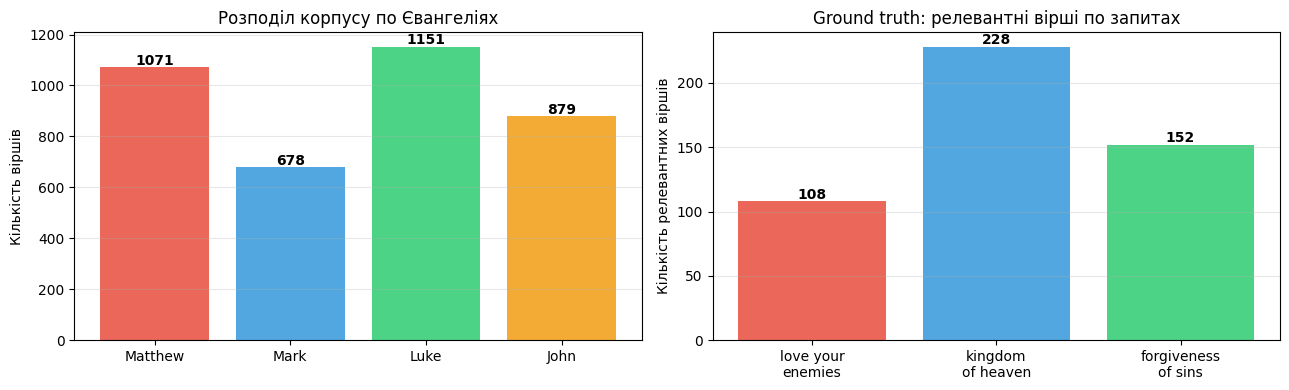

In [18]:
# Діаграма 1 — розподіл корпусу по книгах
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

books = ['Matthew', 'Mark', 'Luke', 'John']
counts = [sum(1 for v in verses if v['book']==b) for b in books]
colors = [book_colors[b] for b in books]

axes[0].bar(books, counts, color=colors, alpha=0.85)
for i, (b, c) in enumerate(zip(books, counts)):
    axes[0].text(i, c+10, str(c), ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Кількість віршів')
axes[0].set_title('Розподіл корпусу по Євангеліях')
axes[0].grid(alpha=0.3, axis='y')

n_rel = [q['n_relevant'] for q in QUERIES]
xlabels = ['love your\nenemies', 'kingdom\nof heaven', 'forgiveness\nof sins']
axes[1].bar(xlabels, n_rel, color=['#e74c3c','#3498db','#2ecc71'], alpha=0.85)
for i, n in enumerate(n_rel):
    axes[1].text(i, n+2, str(n), ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Кількість релевантних віршів')
axes[1].set_title('Ground truth: релевантні вірші по запитах')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('chart_corpus_overview.png', dpi=150, bbox_inches='tight')
plt.show()

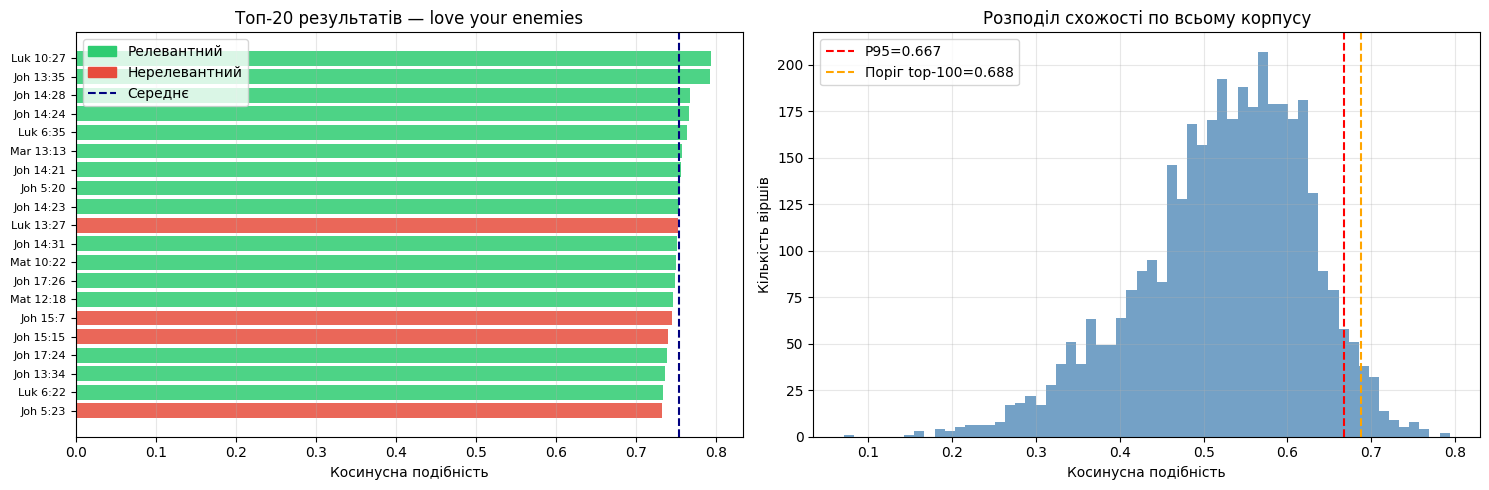

In [19]:
# Діаграма 2 — топ-20 результатів першого запиту
q = QUERIES[0]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# барplot топ-20
top20_scores = q['top_scores'][:20]
top20_labels = [f"{verses[int(i)]['book'][:3]} {verses[int(i)]['chapter']}:{verses[int(i)]['verse']}"
                for i in q['top_indices'][:20]]
bar_colors = ['#2ecc71' if q['relevance'][idx] else '#e74c3c'
              for idx in q['top_indices'][:20]]

axes[0].barh(range(20), top20_scores[::-1], color=bar_colors[::-1], alpha=0.85)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top20_labels[::-1], fontsize=8)
axes[0].set_xlabel('Косинусна подібність')
axes[0].set_title('Топ-20 результатів — love your enemies')
axes[0].axvline(top20_scores.mean(), color='navy', lw=1.5, linestyle='--', label='Середнє')
axes[0].legend(handles=[mpatches.Patch(color='#2ecc71', label='Релевантний'),
                         mpatches.Patch(color='#e74c3c', label='Нерелевантний'),
                         plt.Line2D([0],[0], color='navy', lw=1.5, linestyle='--', label='Середнє')])
axes[0].grid(alpha=0.3, axis='x')

# гістограма розподілу схожості
scores_all = cosine_similarity(q['query_vector'].reshape(1,-1), matrix)[0]
axes[1].hist(scores_all, bins=60, color='steelblue', alpha=0.75, edgecolor='none')
axes[1].axvline(np.percentile(scores_all, 95), color='red', lw=1.5,
                linestyle='--', label=f'P95={np.percentile(scores_all,95):.3f}')
axes[1].axvline(q['top_scores'].min(), color='orange', lw=1.5,
                linestyle='--', label=f'Поріг top-100={q["top_scores"].min():.3f}')
axes[1].set_xlabel('Косинусна подібність')
axes[1].set_ylabel('Кількість віршів')
axes[1].set_title('Розподіл схожості по всьому корпусу')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chart_q1_top20.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
import numpy as np

def make_query_vector(keywords, verses, matrix):
    """Pseudo-Relevance Feedback: mean embedding of verses containing any keyword."""
    idxs = [i for i, v in enumerate(verses)
            if any(kw.lower() in v['text'].lower() for kw in keywords)]
    if not idxs:
        raise ValueError(f"No verses found for keywords: {keywords}")
    return matrix[idxs].mean(axis=0)

# Keywords для кожного запиту
QUERY_KEYWORDS = {
    'love your enemies':      ['enemy', 'enemies', 'love', 'bless', 'curse'],
    'the kingdom of heaven':  ['kingdom', 'heaven', 'inherit', 'reign'],
    'forgiveness of sins':    ['forgiv', 'sin', 'repent', 'remission'],
}

for q in QUERIES:
    kws = QUERY_KEYWORDS.get(q['text'])
    if kws:
        q['vector'] = make_query_vector(kws, verses, matrix)

print("Вектори додано:", [q['text'] for q in QUERIES if 'vector' in q])

Вектори додано: ['love your enemies', 'the kingdom of heaven', 'forgiveness of sins']


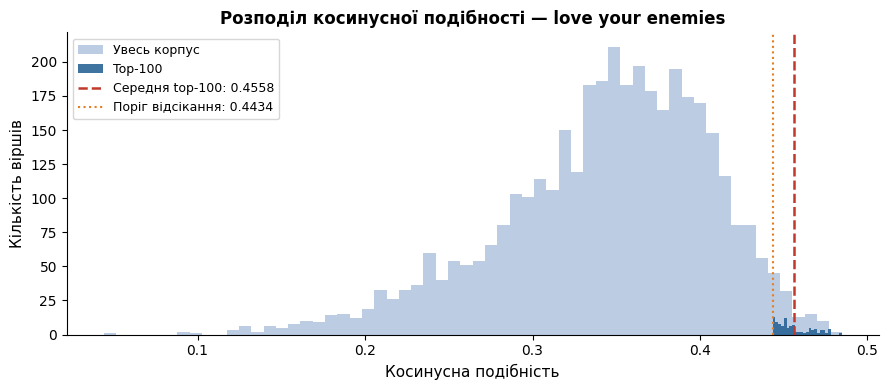

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

q = next(x for x in QUERIES if 'enemies' in x['text'])
result = semantic_search(q['vector'], matrix, k=100)
scores = result['scores']
all_scores = matrix @ q['vector']

fig, ax = plt.subplots(figsize=(9, 4), facecolor='white')
ax.set_facecolor('white')
ax.hist(all_scores, bins=60, color='#b0c4de', alpha=0.85, label='Увесь корпус')
ax.hist(scores, bins=25, color='#2a6496', alpha=0.90, label='Top-100')
ax.axvline(scores.mean(), color='#c0392b', lw=1.8, linestyle='--', label=f'Середня top-100: {scores.mean():.4f}')
ax.axvline(scores.min(),  color='#e67e22', lw=1.5, linestyle=':',  label=f'Поріг відсікання: {scores.min():.4f}')
ax.set_xlabel('Косинусна подібність', fontsize=11)
ax.set_ylabel('Кількість віршів', fontsize=11)
ax.set_title('Розподіл косинусної подібності — love your enemies', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('dist_enemies.png', dpi=150, bbox_inches='tight')
plt.show()

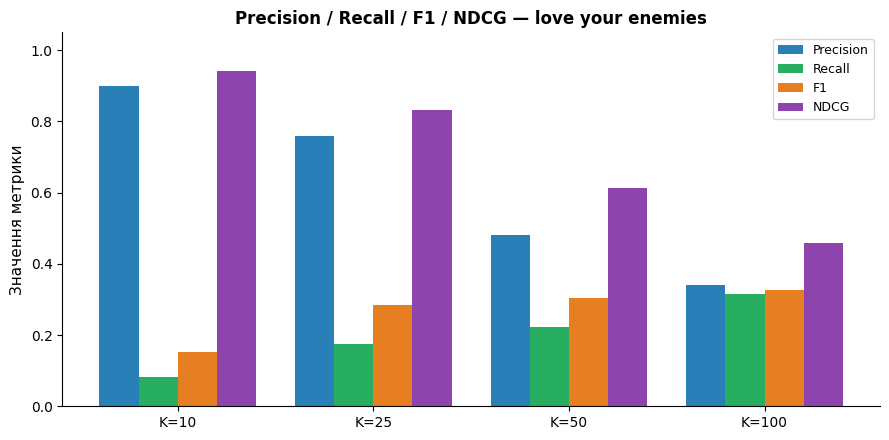

In [25]:
metrics = compute_all_metrics(q)
K_VALUES = [10, 25, 50, 100]

prec  = [metrics[f'P@{k}']    for k in K_VALUES]
rec   = [metrics[f'R@{k}']    for k in K_VALUES]
f1    = [metrics[f'F1@{k}']   for k in K_VALUES]
ndcg  = [metrics[f'NDCG@{k}'] for k in K_VALUES]

x = np.arange(len(K_VALUES))
w = 0.20
fig, ax = plt.subplots(figsize=(9, 4.5), facecolor='white')
ax.set_facecolor('white')
ax.bar(x - 1.5*w, prec,  w, label='Precision', color='#2980b9')
ax.bar(x - 0.5*w, rec,   w, label='Recall',    color='#27ae60')
ax.bar(x + 0.5*w, f1,    w, label='F1',        color='#e67e22')
ax.bar(x + 1.5*w, ndcg,  w, label='NDCG',      color='#8e44ad')
ax.set_xticks(x); ax.set_xticklabels([f'K={k}' for k in K_VALUES])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Значення метрики', fontsize=11)
ax.set_title('Precision / Recall / F1 / NDCG — love your enemies', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('metrics_enemies.png', dpi=150, bbox_inches='tight')
plt.show()

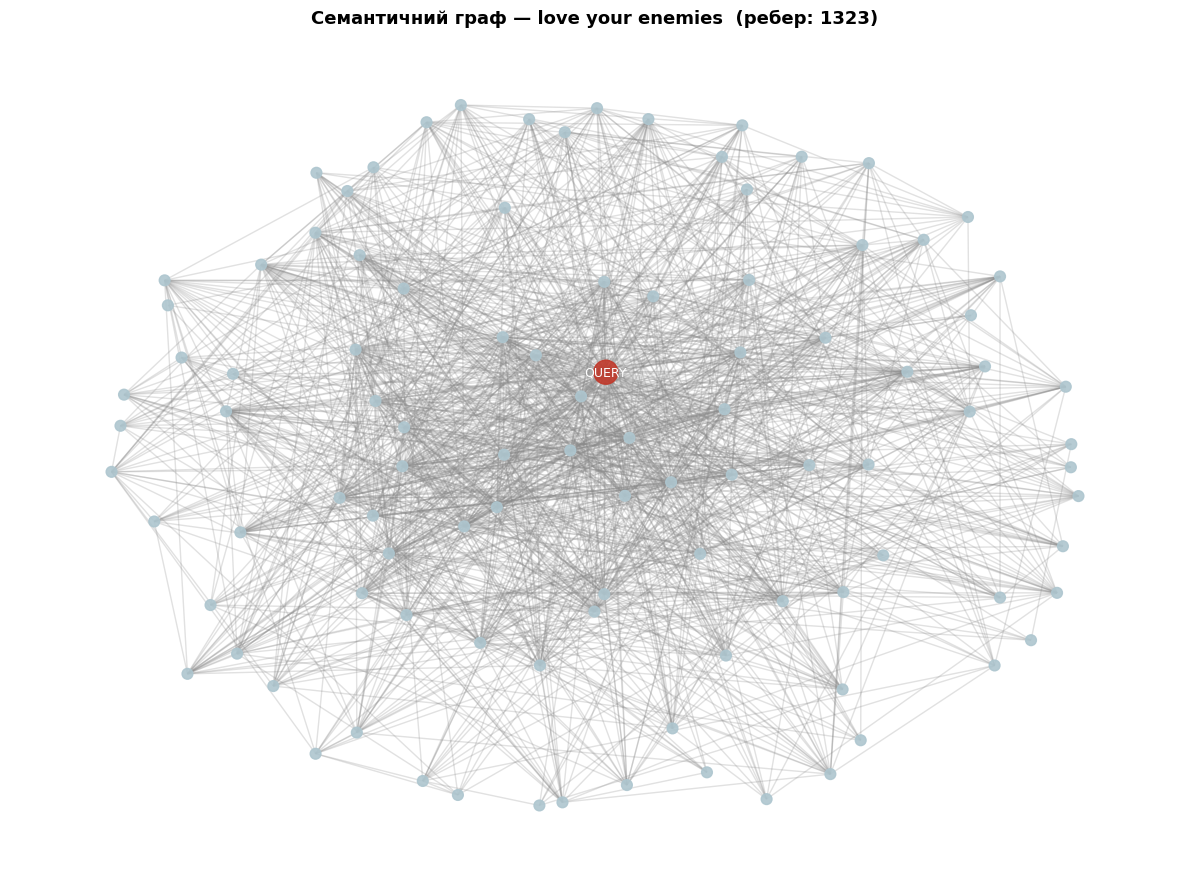

Вузлів: 101, Ребер: 1323


In [26]:
import networkx as nx

result100 = semantic_search(q['vector'], matrix, k=100)
top_idx   = result100['indices']
top_scores = result100['scores']

verse_labels = [f"{verses[i]['book']} {verses[i]['chapter']}:{verses[i]['verse']}" for i in top_idx]
top_emb = matrix[top_idx]
sim_matrix = top_emb @ top_emb.T

THRESHOLD = np.percentile(sim_matrix[sim_matrix < 1.0], 75)
G = nx.Graph()
G.add_node('QUERY', size=25, color='#c0392b')
for i, (idx, sc) in enumerate(zip(top_idx, top_scores)):
    G.add_node(verse_labels[i], size=8 + sc*10, color='#2980b9')
    G.add_edge('QUERY', verse_labels[i], weight=float(sc))
for i in range(len(top_idx)):
    for j in range(i+1, len(top_idx)):
        if sim_matrix[i,j] >= THRESHOLD:
            G.add_edge(verse_labels[i], verse_labels[j], weight=float(sim_matrix[i,j]))

pos = nx.spring_layout(G, seed=42, k=1.8)
fig, ax = plt.subplots(figsize=(12, 9), facecolor='white')
ax.set_facecolor('white')
node_colors = ['#c0392b' if n == 'QUERY' else '#aec6cf' for n in G.nodes()]
node_sizes  = [300 if n == 'QUERY' else 60 for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.25, edge_color='#888888', ax=ax)
nx.draw_networkx_labels(G, pos, {n: n for n in G.nodes() if n == 'QUERY'}, font_size=9, font_color='white', ax=ax)
ax.set_title(f'Семантичний граф — love your enemies  (ребер: {G.number_of_edges()})', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('graph_enemies.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Вузлів: {G.number_of_nodes()}, Ребер: {G.number_of_edges()}")

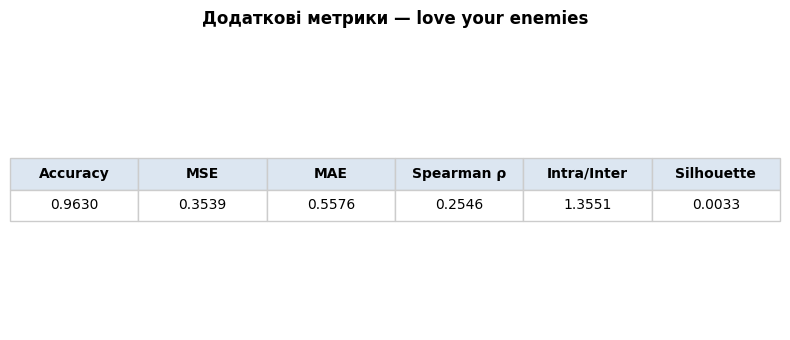

In [29]:
from sklearn.metrics import silhouette_score as sk_silhouette

all_emb   = matrix
top_emb   = matrix[result100['indices']]
other_emb = np.delete(matrix, result100['indices'], axis=0)

intra = float(np.mean(top_emb @ top_emb.T))
inter = float(np.mean(top_emb @ other_emb.T))

# Silhouette на вибірці
sample_idx   = np.random.choice(len(matrix), 500, replace=False)
sample_emb   = matrix[sample_idx]
labels_full  = np.array([1 if i in set(result100['indices']) else 0 for i in range(len(matrix))])
sample_labels = labels_full[sample_idx]
sil = sk_silhouette(sample_emb, sample_labels) if len(set(sample_labels)) > 1 else 0.0

# Зведена таблиця додаткових метрик
add_metrics = {
    'Accuracy': metrics['Accuracy'],
    'MSE':      metrics['MSE'],
    'MAE':      metrics['MAE'],
    'Spearman ρ': metrics['Spearman_rho'],
    'Intra/Inter': metrics['Intra_Inter_ratio'],
    'Silhouette': metrics['Silhouette'],
}

fig, ax = plt.subplots(figsize=(8, 3.5), facecolor='white')
ax.axis('off')
col_labels = list(add_metrics.keys())
row_vals   = [[f"{v:.4f}" for v in add_metrics.values()]]
tbl = ax.table(cellText=row_vals, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.8)
for (r,c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0: cell.set_facecolor('#dce6f1'); cell.set_text_props(fontweight='bold')
    else: cell.set_facecolor('white')
ax.set_title('Додаткові метрики — love your enemies', fontsize=12, fontweight='bold', pad=18)
plt.tight_layout()
plt.savefig('extra_enemies.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
print(metrics.keys())

dict_keys(['P@10', 'R@10', 'F1@10', 'NDCG@10', 'P@25', 'R@25', 'F1@25', 'NDCG@25', 'P@50', 'R@50', 'F1@50', 'NDCG@50', 'P@100', 'R@100', 'F1@100', 'NDCG@100', 'AP', 'Accuracy', 'MSE', 'MAE', 'Spearman_rho', 'Spearman_p', 'Intra_mean', 'Inter_mean', 'Intra_Inter_ratio', 'Silhouette'])


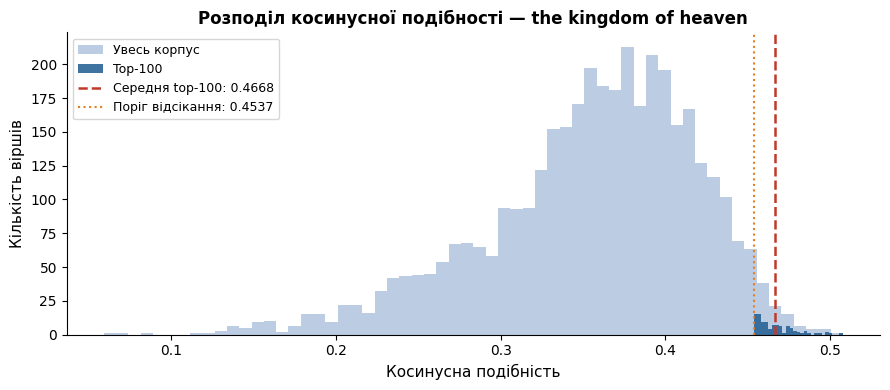

In [30]:
import matplotlib.pyplot as plt
import numpy as np

q = next(x for x in QUERIES if 'kingdom' in x['text'])
result = semantic_search(q['vector'], matrix, k=100)
scores = result['scores']
all_scores = matrix @ q['vector']

fig, ax = plt.subplots(figsize=(9, 4), facecolor='white')
ax.set_facecolor('white')
ax.hist(all_scores, bins=60, color='#b0c4de', alpha=0.85, label='Увесь корпус')
ax.hist(scores, bins=25, color='#2a6496', alpha=0.90, label='Top-100')
ax.axvline(scores.mean(), color='#c0392b', lw=1.8, linestyle='--',
           label=f'Середня top-100: {scores.mean():.4f}')
ax.axvline(scores.min(), color='#e67e22', lw=1.5, linestyle=':',
           label=f'Поріг відсікання: {scores.min():.4f}')
ax.set_xlabel('Косинусна подібність', fontsize=11)
ax.set_ylabel('Кількість віршів', fontsize=11)
ax.set_title('Розподіл косинусної подібності — the kingdom of heaven', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('dist_kingdom.png', dpi=150, bbox_inches='tight')
plt.show()

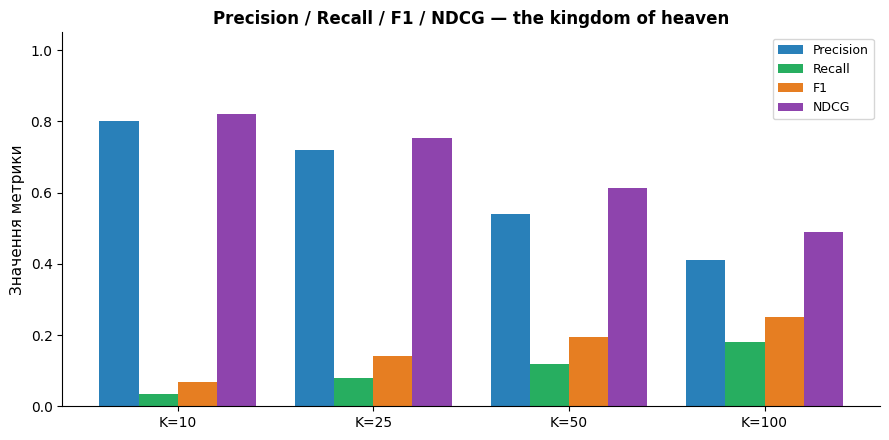

{10: '0.800/0.035/0.067/0.820', 25: '0.720/0.079/0.142/0.752', 50: '0.540/0.118/0.194/0.614', 100: '0.410/0.180/0.250/0.490'}
AP=0.1139


In [31]:
metrics = compute_all_metrics(q)
K_VALUES = [10, 25, 50, 100]

prec  = [metrics[f'P@{k}']    for k in K_VALUES]
rec   = [metrics[f'R@{k}']    for k in K_VALUES]
f1    = [metrics[f'F1@{k}']   for k in K_VALUES]
ndcg  = [metrics[f'NDCG@{k}'] for k in K_VALUES]

x = np.arange(len(K_VALUES))
w = 0.20
fig, ax = plt.subplots(figsize=(9, 4.5), facecolor='white')
ax.set_facecolor('white')
ax.bar(x - 1.5*w, prec,  w, label='Precision', color='#2980b9')
ax.bar(x - 0.5*w, rec,   w, label='Recall',    color='#27ae60')
ax.bar(x + 0.5*w, f1,    w, label='F1',        color='#e67e22')
ax.bar(x + 1.5*w, ndcg,  w, label='NDCG',      color='#8e44ad')
ax.set_xticks(x); ax.set_xticklabels([f'K={k}' for k in K_VALUES])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Значення метрики', fontsize=11)
ax.set_title('Precision / Recall / F1 / NDCG — the kingdom of heaven', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('metrics_kingdom.png', dpi=150, bbox_inches='tight')
plt.show()
print({k: f"{metrics[f'P@{k}']:.3f}/{metrics[f'R@{k}']:.3f}/{metrics[f'F1@{k}']:.3f}/{metrics[f'NDCG@{k}']:.3f}" for k in K_VALUES})
print(f"AP={metrics['AP']:.4f}")

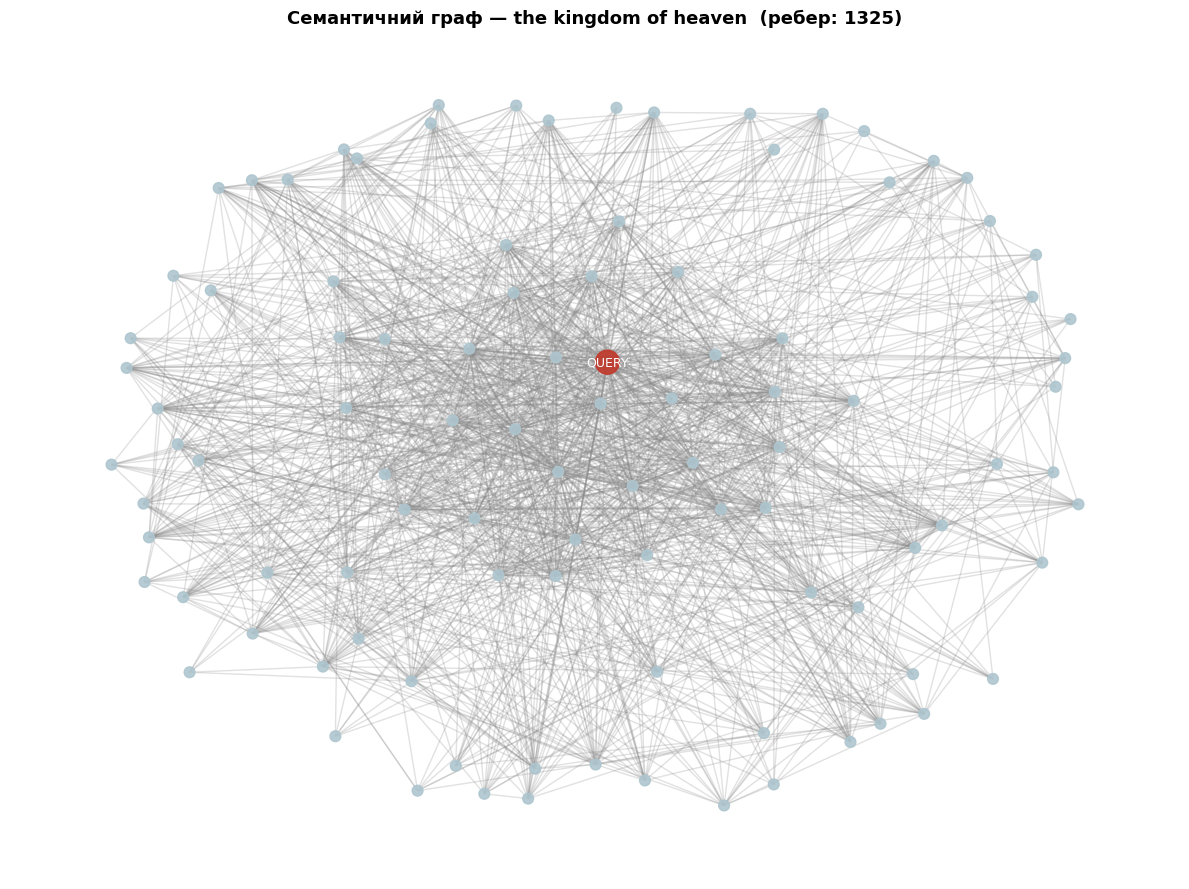

Вузлів: 101, Ребер: 1325


In [32]:
import networkx as nx

top_idx    = result['indices']
top_scores = result['scores']
verse_labels = [f"{verses[i]['book']} {verses[i]['chapter']}:{verses[i]['verse']}" for i in top_idx]
top_emb    = matrix[top_idx]
sim_matrix = top_emb @ top_emb.T

THRESHOLD = np.percentile(sim_matrix[sim_matrix < 1.0], 75)
G = nx.Graph()
G.add_node('QUERY', size=25, color='#c0392b')
for i, (idx, sc) in enumerate(zip(top_idx, top_scores)):
    G.add_node(verse_labels[i], size=8 + sc*10, color='#2980b9')
    G.add_edge('QUERY', verse_labels[i], weight=float(sc))
for i in range(len(top_idx)):
    for j in range(i+1, len(top_idx)):
        if sim_matrix[i,j] >= THRESHOLD:
            G.add_edge(verse_labels[i], verse_labels[j], weight=float(sim_matrix[i,j]))

pos = nx.spring_layout(G, seed=42, k=1.8)
fig, ax = plt.subplots(figsize=(12, 9), facecolor='white')
ax.set_facecolor('white')
node_colors = ['#c0392b' if n == 'QUERY' else '#aec6cf' for n in G.nodes()]
node_sizes  = [300 if n == 'QUERY' else 60 for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.25, edge_color='#888888', ax=ax)
nx.draw_networkx_labels(G, pos, {n: n for n in G.nodes() if n == 'QUERY'},
                        font_size=9, font_color='white', ax=ax)
ax.set_title(f'Семантичний граф — the kingdom of heaven  (ребер: {G.number_of_edges()})', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('graph_kingdom.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Вузлів: {G.number_of_nodes()}, Ребер: {G.number_of_edges()}")

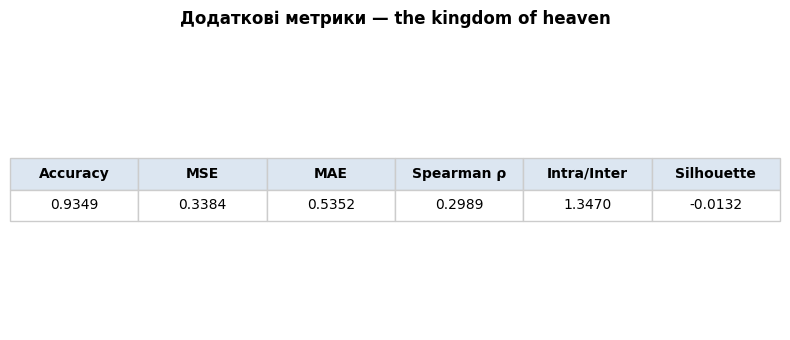

In [33]:
from sklearn.metrics import silhouette_score as sk_silhouette

sample_idx    = np.random.choice(len(matrix), 500, replace=False)
sample_emb    = matrix[sample_idx]
labels_full   = np.array([1 if i in set(result['indices']) else 0 for i in range(len(matrix))])
sample_labels = labels_full[sample_idx]
sil = sk_silhouette(sample_emb, sample_labels) if len(set(sample_labels)) > 1 else 0.0

add_metrics = {
    'Accuracy':   metrics['Accuracy'],
    'MSE':        metrics['MSE'],
    'MAE':        metrics['MAE'],
    'Spearman ρ': metrics['Spearman_rho'],
    'Intra/Inter':metrics['Intra_Inter_ratio'],
    'Silhouette': metrics['Silhouette'],
}

fig, ax = plt.subplots(figsize=(8, 3.5), facecolor='white')
ax.axis('off')
col_labels = list(add_metrics.keys())
row_vals   = [[f"{v:.4f}" for v in add_metrics.values()]]
tbl = ax.table(cellText=row_vals, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.8)
for (r,c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0: cell.set_facecolor('#dce6f1'); cell.set_text_props(fontweight='bold')
    else: cell.set_facecolor('white')
ax.set_title('Додаткові метрики — the kingdom of heaven', fontsize=12, fontweight='bold', pad=18)
plt.tight_layout()
plt.savefig('extra_kingdom.png', dpi=150, bbox_inches='tight')
plt.show()

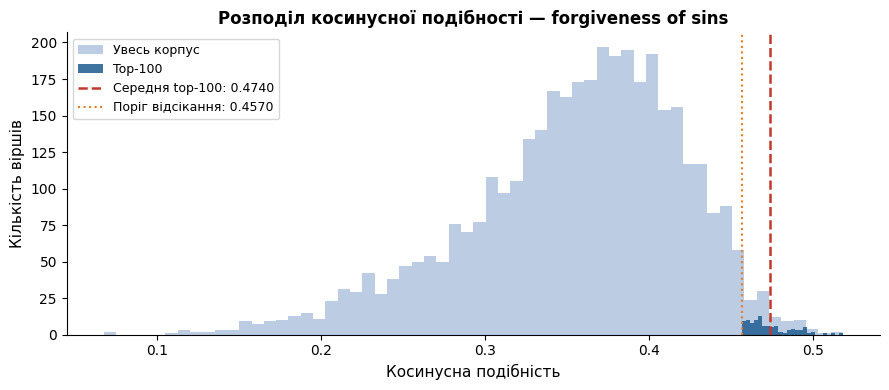

In [34]:
import matplotlib.pyplot as plt
import numpy as np

q = next(x for x in QUERIES if 'forgiveness' in x['text'])
result = semantic_search(q['vector'], matrix, k=100)
scores = result['scores']
all_scores = matrix @ q['vector']

fig, ax = plt.subplots(figsize=(9, 4), facecolor='white')
ax.set_facecolor('white')
ax.hist(all_scores, bins=60, color='#b0c4de', alpha=0.85, label='Увесь корпус')
ax.hist(scores, bins=25, color='#2a6496', alpha=0.90, label='Top-100')
ax.axvline(scores.mean(), color='#c0392b', lw=1.8, linestyle='--',
           label=f'Середня top-100: {scores.mean():.4f}')
ax.axvline(scores.min(), color='#e67e22', lw=1.5, linestyle=':',
           label=f'Поріг відсікання: {scores.min():.4f}')
ax.set_xlabel('Косинусна подібність', fontsize=11)
ax.set_ylabel('Кількість віршів', fontsize=11)
ax.set_title('Розподіл косинусної подібності — forgiveness of sins', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('dist_forgiveness.png', dpi=150, bbox_inches='tight')
plt.show()

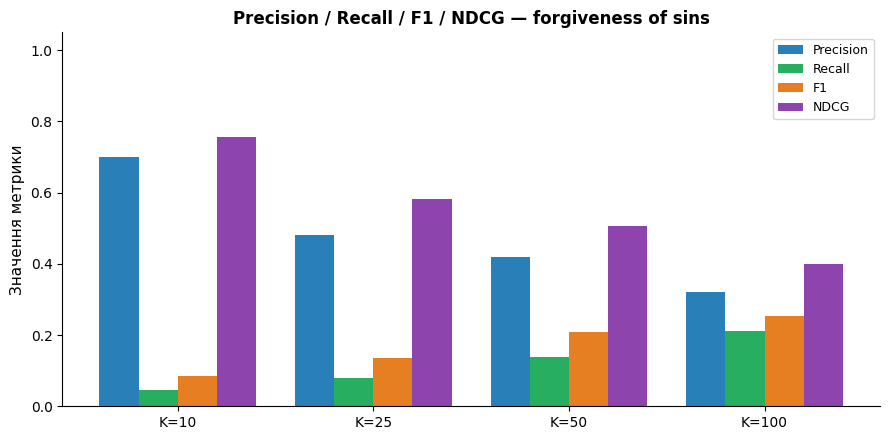

{10: '0.700/0.046/0.086/0.755', 25: '0.480/0.079/0.136/0.581', 50: '0.420/0.138/0.208/0.505', 100: '0.320/0.211/0.254/0.400'}
AP=0.1112


In [35]:
metrics = compute_all_metrics(q)
K_VALUES = [10, 25, 50, 100]

prec  = [metrics[f'P@{k}']    for k in K_VALUES]
rec   = [metrics[f'R@{k}']    for k in K_VALUES]
f1    = [metrics[f'F1@{k}']   for k in K_VALUES]
ndcg  = [metrics[f'NDCG@{k}'] for k in K_VALUES]

x = np.arange(len(K_VALUES))
w = 0.20
fig, ax = plt.subplots(figsize=(9, 4.5), facecolor='white')
ax.set_facecolor('white')
ax.bar(x - 1.5*w, prec,  w, label='Precision', color='#2980b9')
ax.bar(x - 0.5*w, rec,   w, label='Recall',    color='#27ae60')
ax.bar(x + 0.5*w, f1,    w, label='F1',        color='#e67e22')
ax.bar(x + 1.5*w, ndcg,  w, label='NDCG',      color='#8e44ad')
ax.set_xticks(x); ax.set_xticklabels([f'K={k}' for k in K_VALUES])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Значення метрики', fontsize=11)
ax.set_title('Precision / Recall / F1 / NDCG — forgiveness of sins', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('metrics_forgiveness.png', dpi=150, bbox_inches='tight')
plt.show()
print({k: f"{metrics[f'P@{k}']:.3f}/{metrics[f'R@{k}']:.3f}/{metrics[f'F1@{k}']:.3f}/{metrics[f'NDCG@{k}']:.3f}" for k in K_VALUES})
print(f"AP={metrics['AP']:.4f}")

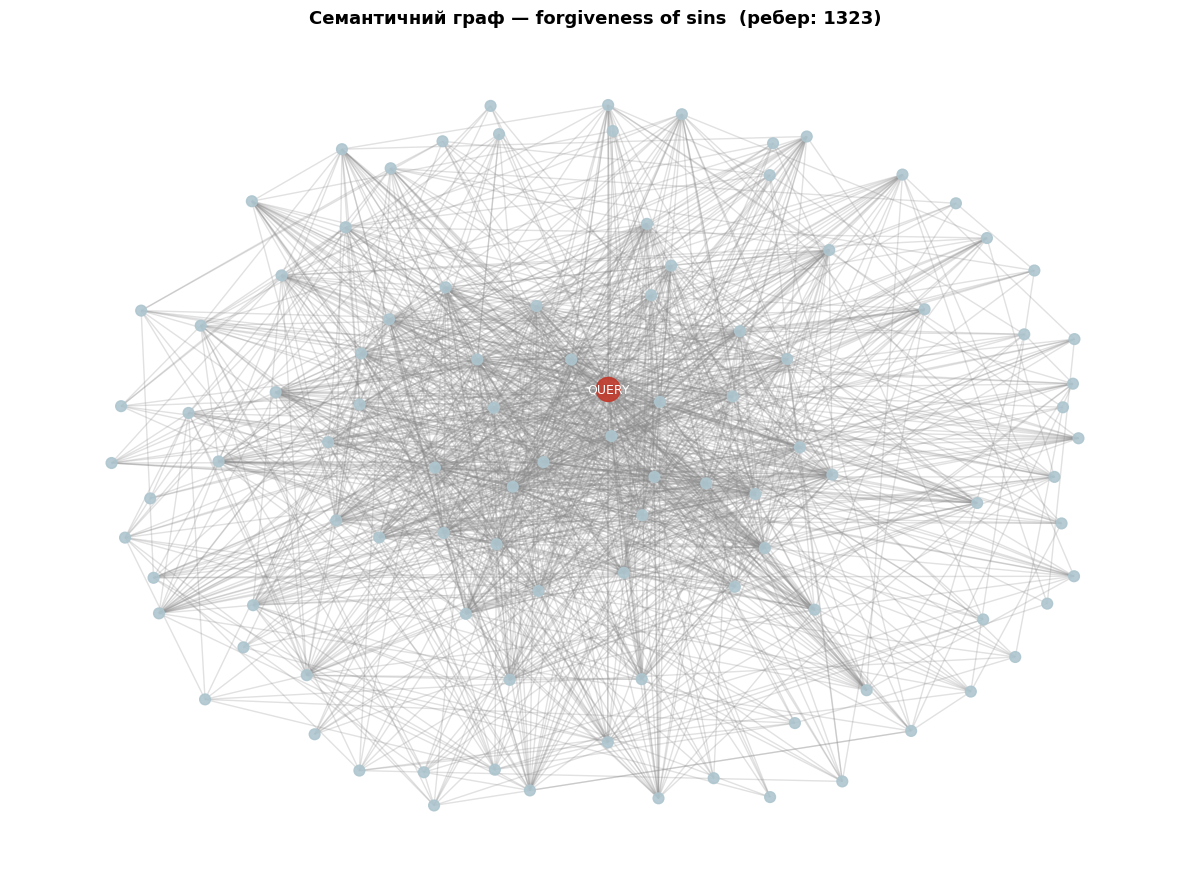

Вузлів: 101, Ребер: 1323


In [36]:
import networkx as nx

top_idx      = result['indices']
top_scores   = result['scores']
verse_labels = [f"{verses[i]['book']} {verses[i]['chapter']}:{verses[i]['verse']}" for i in top_idx]
top_emb      = matrix[top_idx]
sim_matrix   = top_emb @ top_emb.T

THRESHOLD = np.percentile(sim_matrix[sim_matrix < 1.0], 75)
G = nx.Graph()
G.add_node('QUERY', size=25, color='#c0392b')
for i, (idx, sc) in enumerate(zip(top_idx, top_scores)):
    G.add_node(verse_labels[i], size=8 + sc*10, color='#2980b9')
    G.add_edge('QUERY', verse_labels[i], weight=float(sc))
for i in range(len(top_idx)):
    for j in range(i+1, len(top_idx)):
        if sim_matrix[i,j] >= THRESHOLD:
            G.add_edge(verse_labels[i], verse_labels[j], weight=float(sim_matrix[i,j]))

pos = nx.spring_layout(G, seed=42, k=1.8)
fig, ax = plt.subplots(figsize=(12, 9), facecolor='white')
ax.set_facecolor('white')
node_colors = ['#c0392b' if n == 'QUERY' else '#aec6cf' for n in G.nodes()]
node_sizes  = [300 if n == 'QUERY' else 60 for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.25, edge_color='#888888', ax=ax)
nx.draw_networkx_labels(G, pos, {n: n for n in G.nodes() if n == 'QUERY'},
                        font_size=9, font_color='white', ax=ax)
ax.set_title(f'Семантичний граф — forgiveness of sins  (ребер: {G.number_of_edges()})', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('graph_forgiveness.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Вузлів: {G.number_of_nodes()}, Ребер: {G.number_of_edges()}")

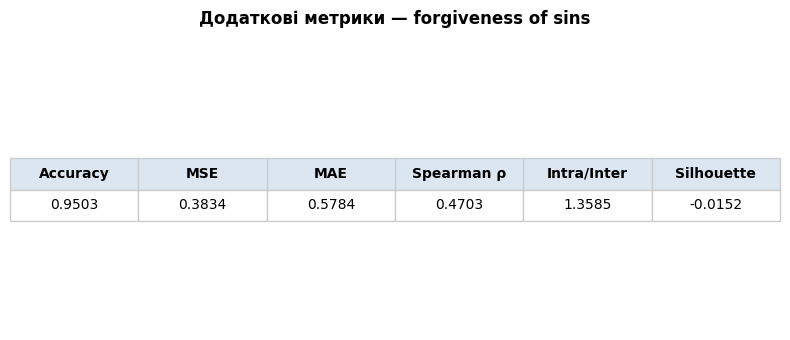

In [37]:
from sklearn.metrics import silhouette_score as sk_silhouette

sample_idx    = np.random.choice(len(matrix), 500, replace=False)
sample_emb    = matrix[sample_idx]
labels_full   = np.array([1 if i in set(result['indices']) else 0 for i in range(len(matrix))])
sample_labels = labels_full[sample_idx]
sil = sk_silhouette(sample_emb, sample_labels) if len(set(sample_labels)) > 1 else 0.0

add_metrics = {
    'Accuracy':    metrics['Accuracy'],
    'MSE':         metrics['MSE'],
    'MAE':         metrics['MAE'],
    'Spearman ρ':  metrics['Spearman_rho'],
    'Intra/Inter': metrics['Intra_Inter_ratio'],
    'Silhouette':  metrics['Silhouette'],
}

fig, ax = plt.subplots(figsize=(8, 3.5), facecolor='white')
ax.axis('off')
col_labels = list(add_metrics.keys())
row_vals   = [[f"{v:.4f}" for v in add_metrics.values()]]
tbl = ax.table(cellText=row_vals, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.8)
for (r,c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0: cell.set_facecolor('#dce6f1'); cell.set_text_props(fontweight='bold')
    else: cell.set_facecolor('white')
ax.set_title('Додаткові метрики — forgiveness of sins', fontsize=12, fontweight='bold', pad=18)
plt.tight_layout()
plt.savefig('extra_forgiveness.png', dpi=150, bbox_inches='tight')
plt.show()

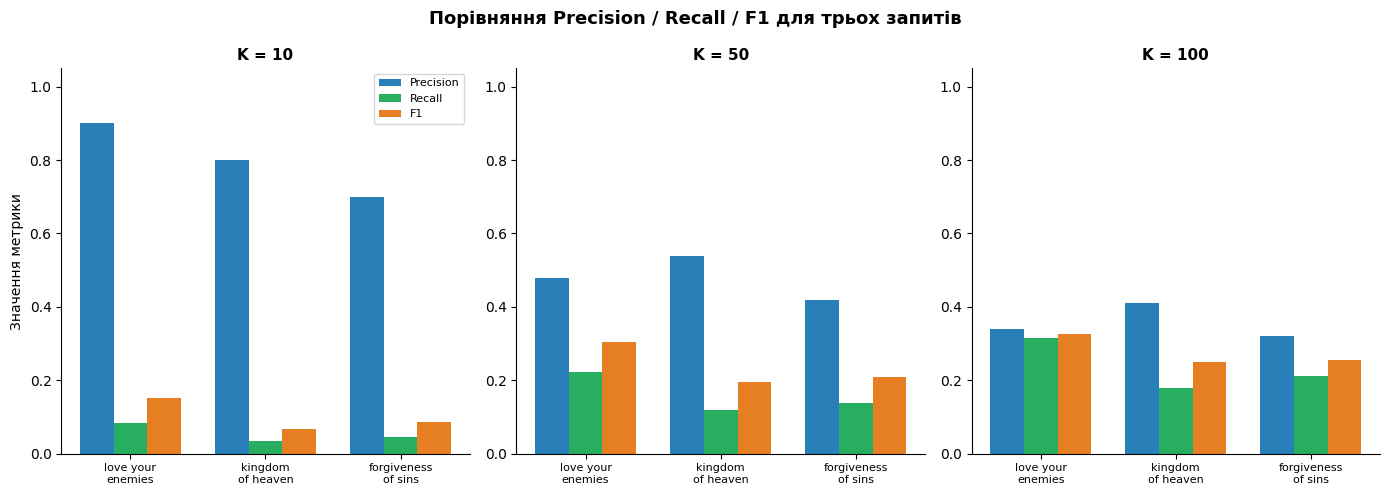

In [38]:
import matplotlib.pyplot as plt
import numpy as np

QUERY_LABELS = ['love your\nenemies', 'kingdom\nof heaven', 'forgiveness\nof sins']
K_SHOW = [10, 50, 100]

all_metrics = {}
for q in QUERIES:
    all_metrics[q['text']] = compute_all_metrics(q)

fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor='white')
colors = ['#2980b9', '#27ae60', '#e67e22']

for ax, k in zip(axes, K_SHOW):
    prec = [all_metrics[q['text']][f'P@{k}'] for q in QUERIES]
    rec  = [all_metrics[q['text']][f'R@{k}'] for q in QUERIES]
    f1   = [all_metrics[q['text']][f'F1@{k}'] for q in QUERIES]
    x = np.arange(3)
    w = 0.25
    ax.set_facecolor('white')
    ax.bar(x - w, prec, w, label='Precision', color=colors[0])
    ax.bar(x,     rec,  w, label='Recall',    color=colors[1])
    ax.bar(x + w, f1,   w, label='F1',        color=colors[2])
    ax.set_xticks(x); ax.set_xticklabels(QUERY_LABELS, fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'K = {k}', fontsize=11, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    if ax == axes[0]:
        ax.set_ylabel('Значення метрики', fontsize=10)
        ax.legend(fontsize=8)

fig.suptitle('Порівняння Precision / Recall / F1 для трьох запитів', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('compare_prf.png', dpi=150, bbox_inches='tight')
plt.show()

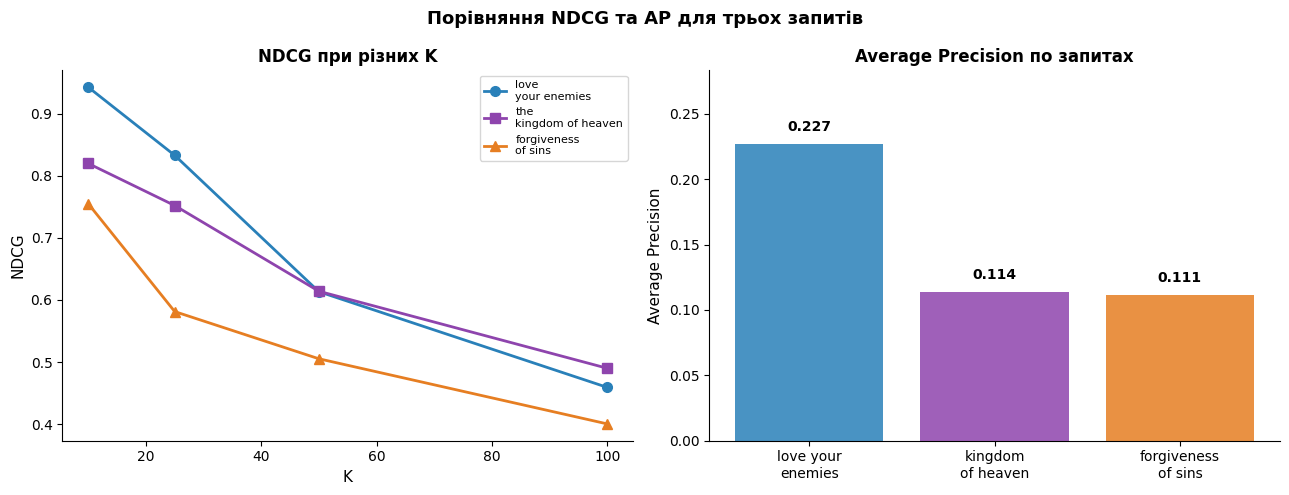

In [39]:
K_VALUES = [10, 25, 50, 100]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
line_styles = ['-o', '-s', '-^']
line_colors = ['#2980b9', '#8e44ad', '#e67e22']

ax = axes[0]
ax.set_facecolor('white')
for q, ls, lc in zip(QUERIES, line_styles, line_colors):
    ndcg_vals = [all_metrics[q['text']][f'NDCG@{k}'] for k in K_VALUES]
    ax.plot(K_VALUES, ndcg_vals, ls, color=lc, lw=2, markersize=7,
            label=q['text'].replace(' ', '\n', 1))
ax.set_xlabel('K', fontsize=11)
ax.set_ylabel('NDCG', fontsize=11)
ax.set_title('NDCG при різних K', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
ax.set_facecolor('white')
ap_vals = [all_metrics[q['text']]['AP'] for q in QUERIES]
bars = ax.bar(QUERY_LABELS, ap_vals, color=['#2980b9','#8e44ad','#e67e22'], alpha=0.85)
for bar, val in zip(bars, ap_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(0, max(ap_vals) * 1.25)
ax.set_ylabel('Average Precision', fontsize=11)
ax.set_title('Average Precision по запитах', fontsize=12, fontweight='bold')
ax.spines[['top','right']].set_visible(False)

fig.suptitle('Порівняння NDCG та AP для трьох запитів', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('compare_ndcg_ap.png', dpi=150, bbox_inches='tight')
plt.show()

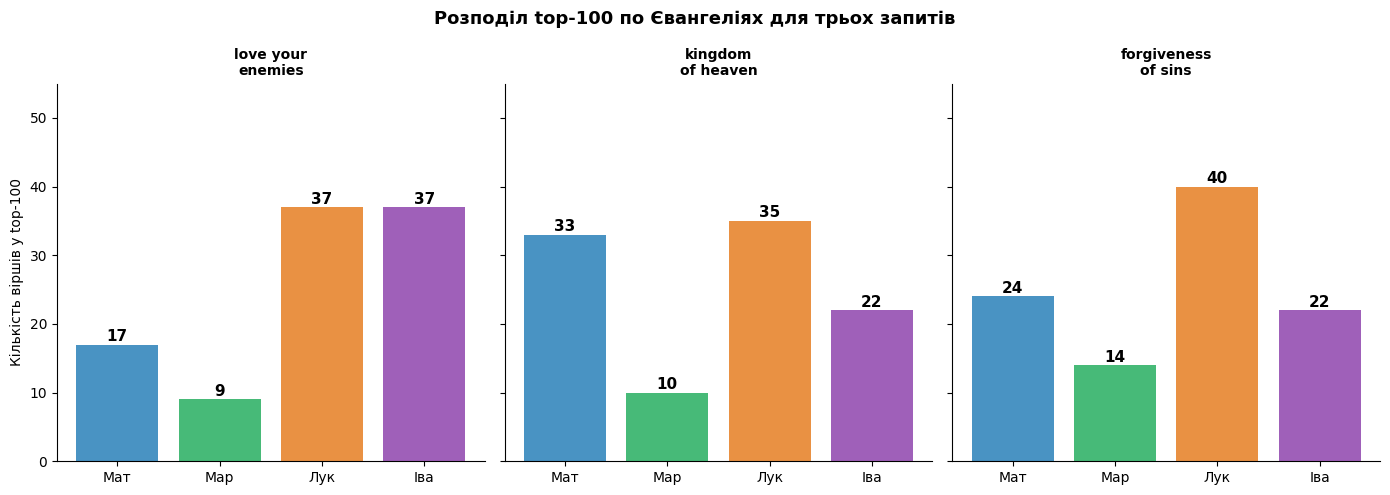

In [40]:
book_order = ['Matthew', 'Mark', 'Luke', 'John']
book_short  = ['Мат', 'Мар', 'Лук', 'Іва']

fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor='white', sharey=True)

for ax, q, title in zip(axes, QUERIES, QUERY_LABELS):
    res = semantic_search(q['vector'], matrix, k=100)
    counts = {b: 0 for b in book_order}
    for idx in res['indices']:
        b = verses[idx]['book']
        if b in counts:
            counts[b] += 1
    vals = [counts[b] for b in book_order]
    bars = ax.bar(book_short, vals,
                  color=['#2980b9','#27ae60','#e67e22','#8e44ad'], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha='center', fontsize=11, fontweight='bold')
    ax.set_facecolor('white')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 55)
    ax.spines[['top','right']].set_visible(False)
    if ax == axes[0]:
        ax.set_ylabel('Кількість віршів у top-100', fontsize=10)

fig.suptitle('Розподіл top-100 по Євангеліях для трьох запитів', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('compare_books.png', dpi=150, bbox_inches='tight')
plt.show()

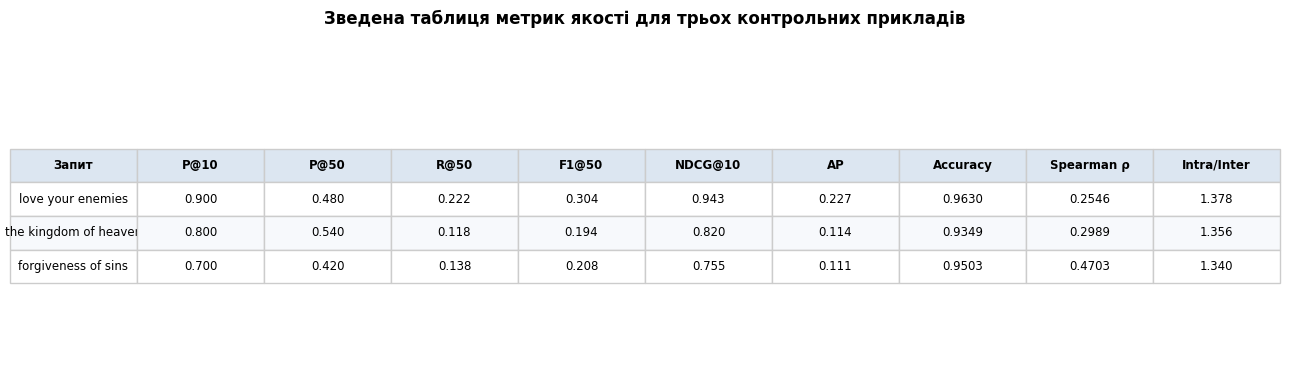

In [41]:
fig, ax = plt.subplots(figsize=(13, 4), facecolor='white')
ax.axis('off')

col_labels = ['Запит', 'P@10', 'P@50', 'R@50', 'F1@50', 'NDCG@10', 'AP',
              'Accuracy', 'Spearman ρ', 'Intra/Inter']
rows = []
for q in QUERIES:
    m = all_metrics[q['text']]
    rows.append([
        q['text'],
        f"{m['P@10']:.3f}",
        f"{m['P@50']:.3f}",
        f"{m['R@50']:.3f}",
        f"{m['F1@50']:.3f}",
        f"{m['NDCG@10']:.3f}",
        f"{m['AP']:.3f}",
        f"{m['Accuracy']:.4f}",
        f"{m['Spearman_rho']:.4f}",
        f"{m['Intra_Inter_ratio']:.3f}",
    ])

tbl = ax.table(cellText=rows, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1, 1.9)
for (r,c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0:
        cell.set_facecolor('#dce6f1')
        cell.set_text_props(fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f7f9fc')
    else:
        cell.set_facecolor('white')

ax.set_title('Зведена таблиця метрик якості для трьох контрольних прикладів',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('compare_table.png', dpi=150, bbox_inches='tight')
plt.show()

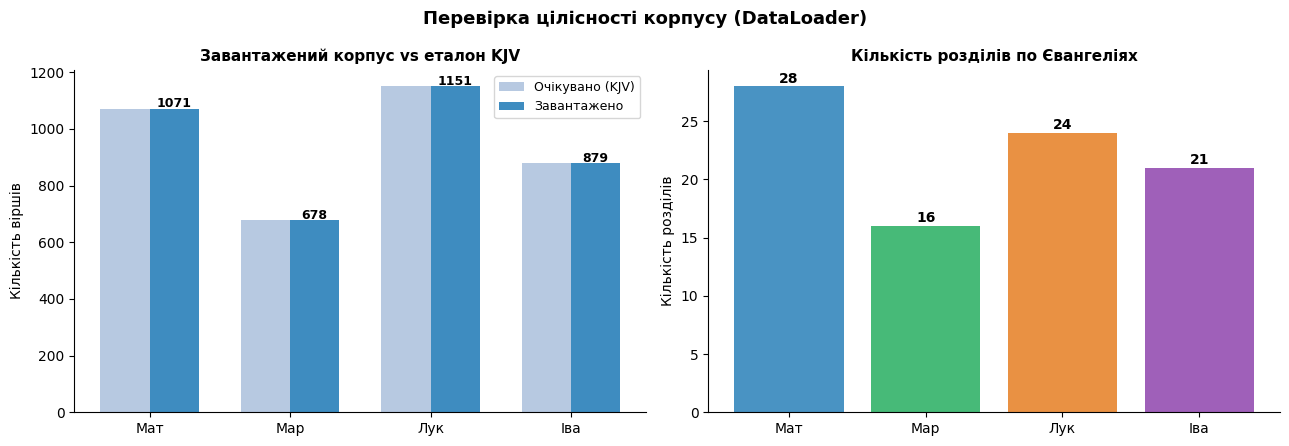

Загальна кількість віршів: 3779
Збіг з еталоном: True


In [42]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

book_order = ['Matthew', 'Mark', 'Luke', 'John']
book_short  = ['Мат', 'Мар', 'Лук', 'Іва']

book_counts   = Counter(v['book']    for v in verses)
chapter_counts = Counter((v['book'], v['chapter']) for v in verses)

expected = {'Matthew': 1071, 'Mark': 678, 'Luke': 1151, 'John': 879}
actual   = {b: book_counts[b] for b in book_order}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor='white')

ax = axes[0]
ax.set_facecolor('white')
x = np.arange(4)
w = 0.35
bars_exp = ax.bar(x - w/2, [expected[b] for b in book_order], w,
                  label='Очікувано (KJV)', color='#b0c4de', alpha=0.9)
bars_act = ax.bar(x + w/2, [actual[b]   for b in book_order], w,
                  label='Завантажено', color='#2980b9', alpha=0.9)
for bar, val in zip(bars_act, [actual[b] for b in book_order]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(book_short)
ax.set_ylabel('Кількість віршів', fontsize=10)
ax.set_title('Завантажений корпус vs еталон KJV', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
ax.set_facecolor('white')
chapters_per_book = {}
for b in book_order:
    chapters_per_book[b] = len(set(ch for (bk, ch) in chapter_counts if bk == b))
bars2 = ax.bar(book_short, [chapters_per_book[b] for b in book_order],
               color=['#2980b9','#27ae60','#e67e22','#8e44ad'], alpha=0.85)
for bar, val in zip(bars2, [chapters_per_book[b] for b in book_order]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Кількість розділів', fontsize=10)
ax.set_title('Кількість розділів по Євангеліях', fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)

fig.suptitle('Перевірка цілісності корпусу (DataLoader)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('check_dataloader.png', dpi=150, bbox_inches='tight')
plt.show()

total = sum(actual.values())
print(f"Загальна кількість віршів: {total}")
print(f"Збіг з еталоном: {all(actual[b] == expected[b] for b in book_order)}")

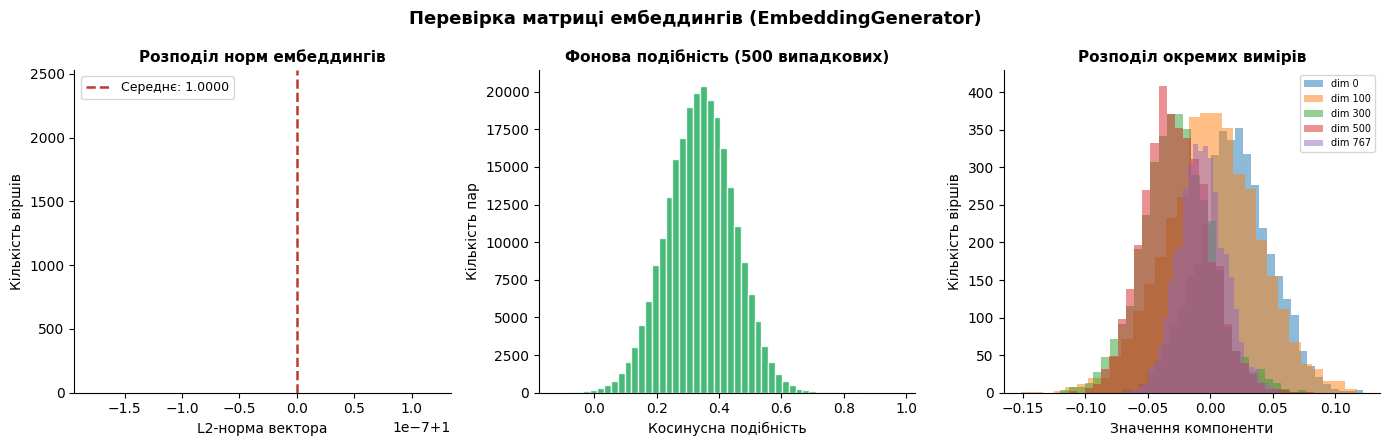

Розмірність матриці: (3779, 768)
Норми: min=1.0000, max=1.0000, std=0.000000
NaN: 0, Inf: 0


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), facecolor='white')

ax = axes[0]
ax.set_facecolor('white')
norms = np.linalg.norm(matrix, axis=1)
ax.hist(norms, bins=40, color='#2980b9', alpha=0.85, edgecolor='white')
ax.axvline(norms.mean(), color='#c0392b', lw=1.8, linestyle='--',
           label=f'Середнє: {norms.mean():.4f}')
ax.set_xlabel('L2-норма вектора', fontsize=10)
ax.set_ylabel('Кількість віршів', fontsize=10)
ax.set_title('Розподіл норм ембеддингів', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
ax.set_facecolor('white')
sample_idx = np.random.choice(len(matrix), 500, replace=False)
sample_sim = (matrix[sample_idx] @ matrix[sample_idx].T).flatten()
sample_sim = sample_sim[sample_sim < 0.9999]
ax.hist(sample_sim, bins=50, color='#27ae60', alpha=0.85, edgecolor='white')
ax.set_xlabel('Косинусна подібність', fontsize=10)
ax.set_ylabel('Кількість пар', fontsize=10)
ax.set_title('Фонова подібність (500 випадкових)', fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)

ax = axes[2]
ax.set_facecolor('white')
dims_to_check = [0, 100, 300, 500, 767]
for d in dims_to_check:
    ax.hist(matrix[:, d], bins=30, alpha=0.5, label=f'dim {d}')
ax.set_xlabel('Значення компоненти', fontsize=10)
ax.set_ylabel('Кількість віршів', fontsize=10)
ax.set_title('Розподіл окремих вимірів', fontsize=11, fontweight='bold')
ax.legend(fontsize=7)
ax.spines[['top','right']].set_visible(False)

fig.suptitle('Перевірка матриці ембеддингів (EmbeddingGenerator)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('check_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Розмірність матриці: {matrix.shape}")
print(f"Норми: min={norms.min():.4f}, max={norms.max():.4f}, std={norms.std():.6f}")
print(f"NaN: {np.isnan(matrix).sum()}, Inf: {np.isinf(matrix).sum()}")

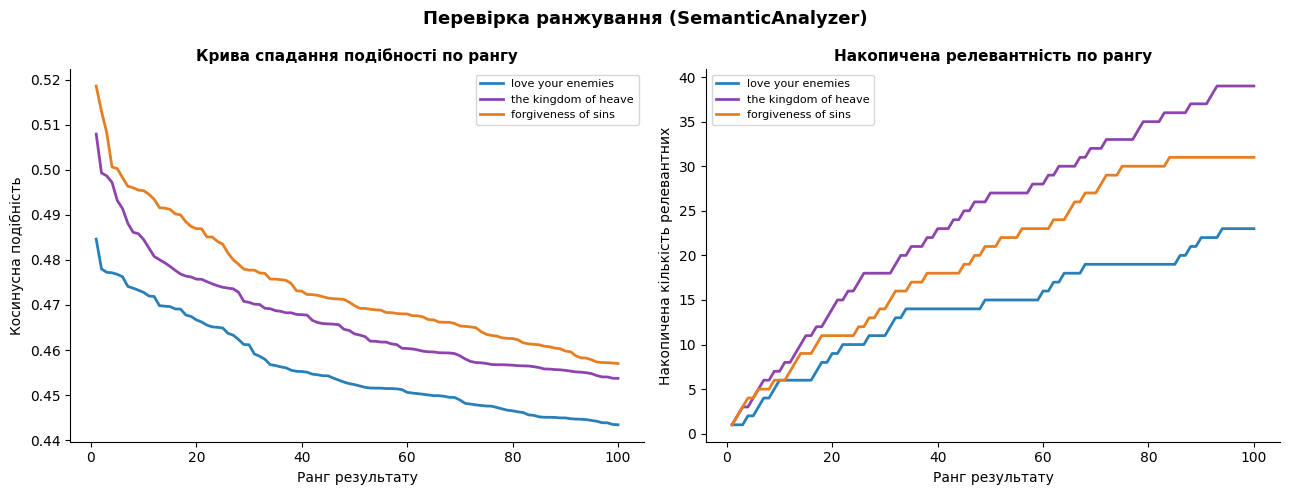

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

ax = axes[0]
ax.set_facecolor('white')
colors_q = ['#2980b9', '#8e44ad', '#e67e22']
for q, lc in zip(QUERIES, colors_q):
    res = semantic_search(q['vector'], matrix, k=100)
    sc  = res['scores']
    ax.plot(range(1, 101), sc, lw=2, color=lc,
            label=q['text'][:20])
ax.set_xlabel('Ранг результату', fontsize=10)
ax.set_ylabel('Косинусна подібність', fontsize=10)
ax.set_title('Крива спадання подібності по рангу', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
ax.set_facecolor('white')
for q, lc in zip(QUERIES, colors_q):
    m = all_metrics[q['text']]
    cumulative_rel = []
    res = semantic_search(q['vector'], matrix, k=100)
    relevant_set = set(
        i for i, v in enumerate(verses)
        if any(kw.lower() in v['text'].lower()
               for kw in ['forgiv','sin','repent'] if 'forgiv' in q['text'])
        or any(kw.lower() in v['text'].lower()
               for kw in ['kingdom','heaven'] if 'kingdom' in q['text'])
        or any(kw.lower() in v['text'].lower()
               for kw in ['enemy','enemies','love','bless'] if 'enemies' in q['text'])
    )
    cum = 0
    vals = []
    for idx in res['indices']:
        if idx in relevant_set:
            cum += 1
        vals.append(cum)
    ax.plot(range(1, 101), vals, lw=2, color=lc, label=q['text'][:20])

ax.set_xlabel('Ранг результату', fontsize=10)
ax.set_ylabel('Накопичена кількість релевантних', fontsize=10)
ax.set_title('Накопичена релевантність по рангу', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)

fig.suptitle('Перевірка ранжування (SemanticAnalyzer)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('check_analyzer.png', dpi=150, bbox_inches='tight')
plt.show()

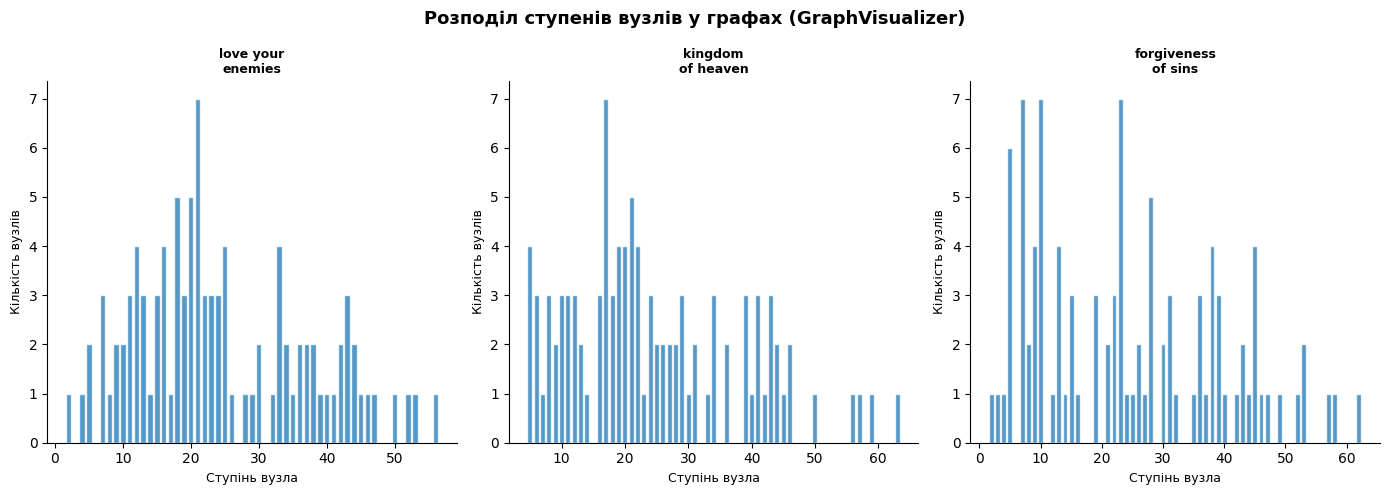

love your enemies         | вузлів 100 | ребер 1223 | max_deg  56 | avg_deg 24.46 | компонент 1
the kingdom of heaven     | вузлів 100 | ребер 1225 | max_deg  63 | avg_deg 24.50 | компонент 1
forgiveness of sins       | вузлів 100 | ребер 1223 | max_deg  62 | avg_deg 24.46 | компонент 1


In [45]:
import networkx as nx

fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor='white')
graph_stats = []

for ax, q, title in zip(axes, QUERIES, QUERY_LABELS):
    res      = semantic_search(q['vector'], matrix, k=100)
    top_idx  = res['indices']
    top_emb  = matrix[top_idx]
    sim_mat  = top_emb @ top_emb.T
    threshold = np.percentile(sim_mat[sim_mat < 1.0], 75)

    G = nx.Graph()
    verse_labels = [f"{verses[i]['book'][:3]} {verses[i]['chapter']}:{verses[i]['verse']}"
                    for i in top_idx]
    for i in range(len(top_idx)):
        for j in range(i+1, len(top_idx)):
            if sim_mat[i,j] >= threshold:
                G.add_edge(verse_labels[i], verse_labels[j])

    degrees = [d for _, d in G.degree()]
    degree_counts = Counter(degrees)
    max_deg = max(degrees) if degrees else 0
    avg_deg = np.mean(degrees) if degrees else 0

    ax.set_facecolor('white')
    ax.bar(degree_counts.keys(), degree_counts.values(),
           color='#2980b9', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Ступінь вузла', fontsize=9)
    ax.set_ylabel('Кількість вузлів', fontsize=9)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

    graph_stats.append({
        'query': q['text'],
        'nodes': G.number_of_nodes(),
        'edges': G.number_of_edges(),
        'max_degree': max_deg,
        'avg_degree': round(avg_deg, 2),
        'components': nx.number_connected_components(G),
    })

fig.suptitle('Розподіл ступенів вузлів у графах (GraphVisualizer)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('check_graph.png', dpi=150, bbox_inches='tight')
plt.show()

for s in graph_stats:
    print(f"{s['query'][:25]:25s} | вузлів {s['nodes']:3d} | ребер {s['edges']:4d} | "
          f"max_deg {s['max_degree']:3d} | avg_deg {s['avg_degree']:.2f} | "
          f"компонент {s['components']}")

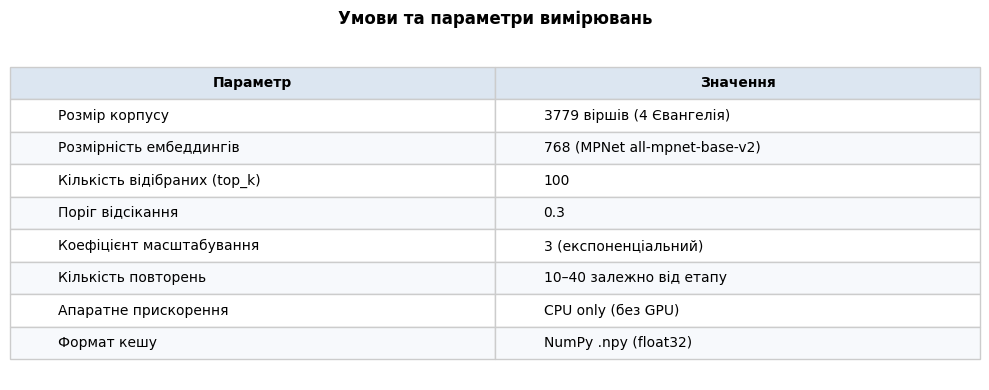

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(10, 4), facecolor='white')
ax.set_facecolor('white')
ax.axis('off')

columns = ['Параметр', 'Значення']
rows = [
    ['Розмір корпусу',            '3779 віршів (4 Євангелія)'],
    ['Розмірність ембеддингів',   '768 (MPNet all-mpnet-base-v2)'],
    ['Кількість відібраних (top_k)', '100'],
    ['Поріг відсікання',          '0.3'],
    ['Коефіцієнт масштабування',  '3 (експоненціальний)'],
    ['Кількість повторень',       '10–40 залежно від етапу'],
    ['Апаратне прискорення',      'CPU only (без GPU)'],
    ['Формат кешу',               'NumPy .npy (float32)'],
]

tbl = ax.table(cellText=rows, colLabels=columns, loc='center', cellLoc='left')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0:
        cell.set_facecolor('#dce6f1')
        cell.set_text_props(fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f7f9fc')
    else:
        cell.set_facecolor('white')

ax.set_title('Умови та параметри вимірювань', fontsize=12, fontweight='bold', pad=16)
plt.tight_layout()
plt.savefig('methodology_params.png', dpi=150, bbox_inches='tight')
plt.show()

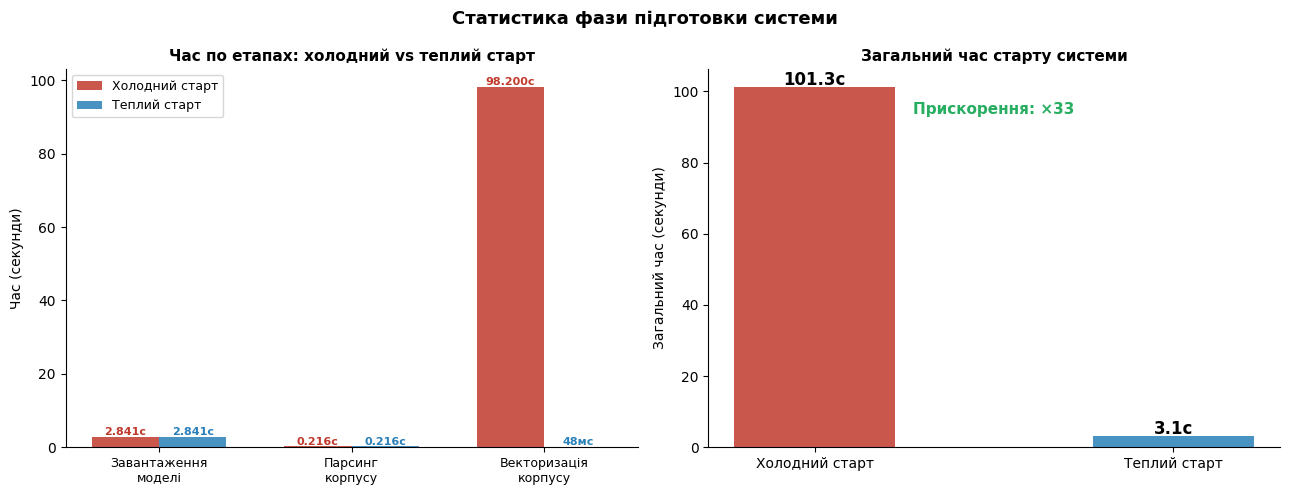

In [47]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

# Ліва панель — розбивка по етапах
ax = axes[0]
ax.set_facecolor('white')

stages_cold = ['Завантаження\nмоделі', 'Парсинг\nкорпусу', 'Векторизація\nкорпусу']
stages_warm = ['Завантаження\nмоделі', 'Парсинг\nкорпусу', 'Читання\nкешу']
times_cold  = [2.841, 0.216, 98.2]
times_warm  = [2.841, 0.216, 0.048]

x = np.arange(3)
w = 0.35
bars1 = ax.bar(x - w/2, times_cold, w, label='Холодний старт', color='#c0392b', alpha=0.85)
bars2 = ax.bar(x + w/2, times_warm, w, label='Теплий старт',   color='#2980b9', alpha=0.85)
for bar, val in zip(bars1, times_cold):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.3f}с', ha='center', fontsize=8, fontweight='bold', color='#c0392b')
for bar, val in zip(bars2, times_warm):
    label = f'{val:.3f}с' if val >= 0.1 else f'{val*1000:.0f}мс'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            label, ha='center', fontsize=8, fontweight='bold', color='#2980b9')
ax.set_xticks(x)
ax.set_xticklabels(stages_cold, fontsize=9)
ax.set_ylabel('Час (секунди)', fontsize=10)
ax.set_title('Час по етапах: холодний vs теплий старт', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# Права панель — загальний час
ax = axes[1]
ax.set_facecolor('white')
totals = [101.3, 3.1]
colors = ['#c0392b', '#2980b9']
bars = ax.bar(['Холодний старт', 'Теплий старт'], totals, color=colors, alpha=0.85, width=0.45)
for bar, val in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}с', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Загальний час (секунди)', fontsize=10)
ax.set_title('Загальний час старту системи', fontsize=11, fontweight='bold')
ax.annotate(f'Прискорення: ×{101.3/3.1:.0f}', xy=(0.5, 0.88),
            xycoords='axes fraction', ha='center', fontsize=11,
            color='#27ae60', fontweight='bold')
ax.spines[['top','right']].set_visible(False)

fig.suptitle('Статистика фази підготовки системи', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('startup_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

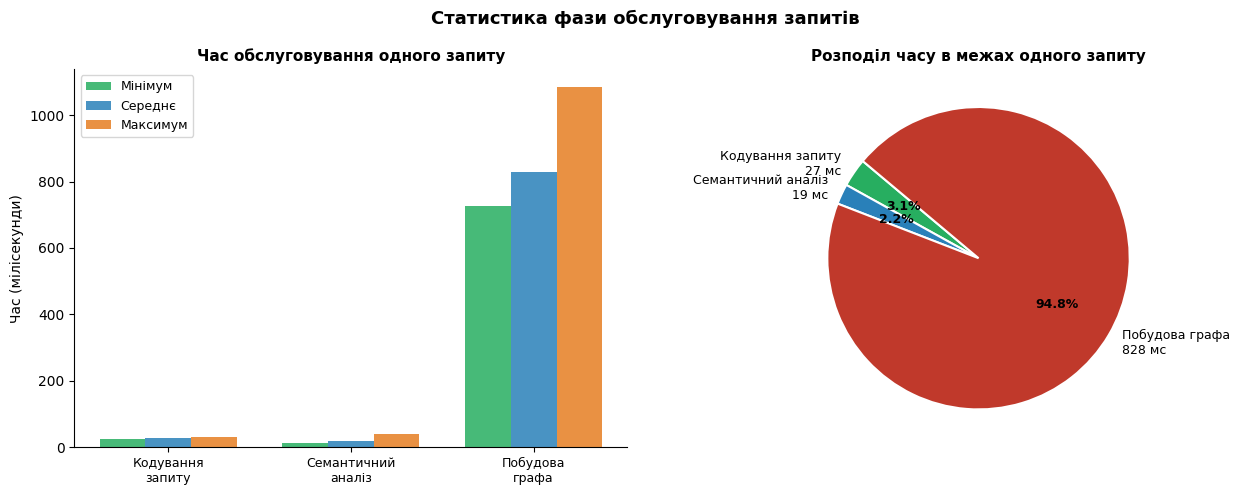

Загальний час одного запиту (середнє): 873.7 мс


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

# Ліва панель — розбивка часу одного запиту
ax = axes[0]
ax.set_facecolor('white')

stages  = ['Кодування\nзапиту', 'Семантичний\nаналіз', 'Побудова\nграфа']
t_min   = [25.6,  12.0, 726.0]
t_mean  = [26.7,  19.0, 828.0]
t_max   = [30.0,  41.0, 1084.0]

x = np.arange(3)
w = 0.25
ax.bar(x - w, t_min,  w, label='Мінімум', color='#27ae60', alpha=0.85)
ax.bar(x,     t_mean, w, label='Середнє', color='#2980b9', alpha=0.85)
ax.bar(x + w, t_max,  w, label='Максимум', color='#e67e22', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=9)
ax.set_ylabel('Час (мілісекунди)', fontsize=10)
ax.set_title('Час обслуговування одного запиту', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# Права панель — кругова діаграма частки часу
ax = axes[1]
ax.set_facecolor('white')
fractions = [26.7, 19.0, 828.0]
labels    = [f'Кодування запиту\n{26.7:.0f} мс', 
             f'Семантичний аналіз\n{19.0:.0f} мс',
             f'Побудова графа\n{828:.0f} мс']
colors_pie = ['#27ae60', '#2980b9', '#c0392b']
wedges, texts, autotexts = ax.pie(
    fractions, labels=labels, colors=colors_pie,
    autopct='%1.1f%%', startangle=140,
    textprops={'fontsize': 9},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Розподіл часу в межах одного запиту', fontsize=11, fontweight='bold')

fig.suptitle('Статистика фази обслуговування запитів', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('query_serving.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Загальний час одного запиту (середнє): {26.7+19.0+828:.1f} мс")

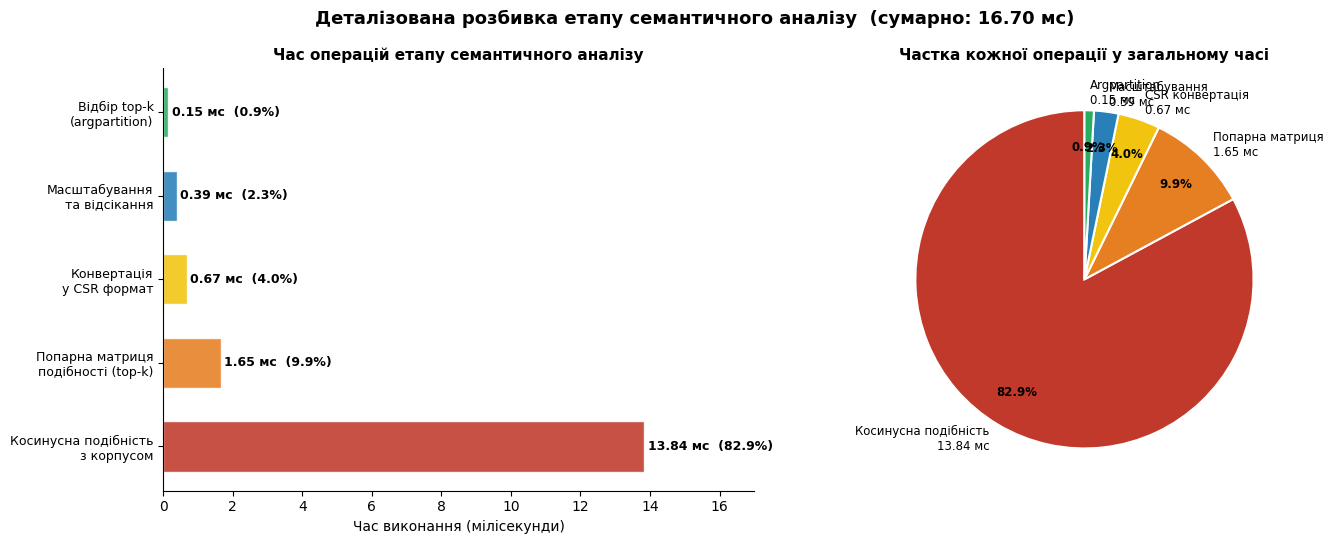

In [49]:
import matplotlib.pyplot as plt
import numpy as np

operations = [
    'Косинусна подібність\nз корпусом',
    'Попарна матриця\nподібності (top-k)',
    'Конвертація\nу CSR формат',
    'Масштабування\nта відсікання',
    'Відбір top-k\n(argpartition)',
]
times_ms = [13.84, 1.65, 0.67, 0.39, 0.15]
total = sum(times_ms)
colors = ['#c0392b', '#e67e22', '#f1c40f', '#2980b9', '#27ae60']

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor='white')

# Ліва панель — горизонтальна гістограма
ax = axes[0]
ax.set_facecolor('white')
y = np.arange(len(operations))
bars = ax.barh(y, times_ms, color=colors, alpha=0.88, edgecolor='white', height=0.6)
for bar, val in zip(bars, times_ms):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f} мс  ({val/total*100:.1f}%)',
            va='center', fontsize=9, fontweight='bold')
ax.set_yticks(y)
ax.set_yticklabels(operations, fontsize=9)
ax.set_xlabel('Час виконання (мілісекунди)', fontsize=10)
ax.set_title('Час операцій етапу семантичного аналізу', fontsize=11, fontweight='bold')
ax.set_xlim(0, 17)
ax.spines[['top','right']].set_visible(False)

# Права панель — кругова діаграма
ax = axes[1]
ax.set_facecolor('white')
short_labels = [
    f'Косинусна подібність\n{times_ms[0]:.2f} мс',
    f'Попарна матриця\n{times_ms[1]:.2f} мс',
    f'CSR конвертація\n{times_ms[2]:.2f} мс',
    f'Масштабування\n{times_ms[3]:.2f} мс',
    f'Argpartition\n{times_ms[4]:.2f} мс',
]
wedges, texts, autotexts = ax.pie(
    times_ms, labels=short_labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 8.5},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    pctdistance=0.78
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Частка кожної операції у загальному часі', fontsize=11, fontweight='bold')

fig.suptitle(f'Деталізована розбивка етапу семантичного аналізу  (сумарно: {total:.2f} мс)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('analysis_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

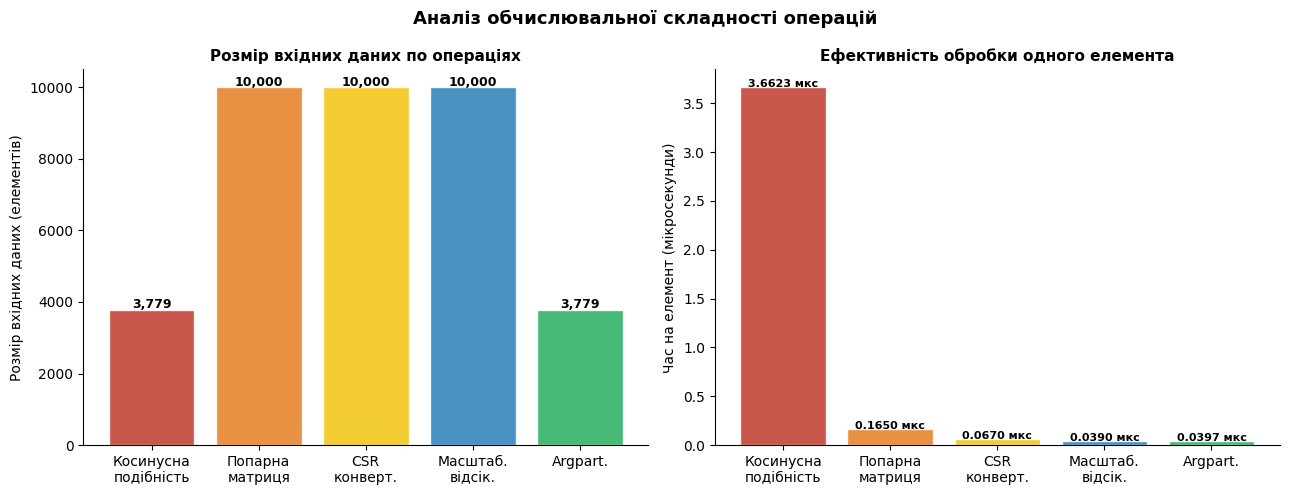

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

# Ліва панель — розмір вхідних даних для кожної операції
ax = axes[0]
ax.set_facecolor('white')
op_short = ['Косинусна\nподібність', 'Попарна\nматриця', 'CSR\nконверт.', 'Масштаб.\nвідсік.', 'Argpart.']
input_sizes = [3779, 100*100, 100*100, 100*100, 3779]
bar_colors = ['#c0392b', '#e67e22', '#f1c40f', '#2980b9', '#27ae60']
bars = ax.bar(op_short, input_sizes, color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, input_sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Розмір вхідних даних (елементів)', fontsize=10)
ax.set_title('Розмір вхідних даних по операціях', fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)

# Права панель — ефективність: час на елемент
ax = axes[1]
ax.set_facecolor('white')
time_per_element = [
    times_ms[0] / 3779 * 1000,
    times_ms[1] / (100*100) * 1000,
    times_ms[2] / (100*100) * 1000,
    times_ms[3] / (100*100) * 1000,
    times_ms[4] / 3779 * 1000,
]
bars2 = ax.bar(op_short, time_per_element, color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars2, time_per_element):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
            f'{val:.4f} мкс', ha='center', fontsize=8, fontweight='bold')
ax.set_ylabel('Час на елемент (мікросекунди)', fontsize=10)
ax.set_title('Ефективність обробки одного елемента', fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)

fig.suptitle('Аналіз обчислювальної складності операцій', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('analysis_complexity.png', dpi=150, bbox_inches='tight')
plt.show()

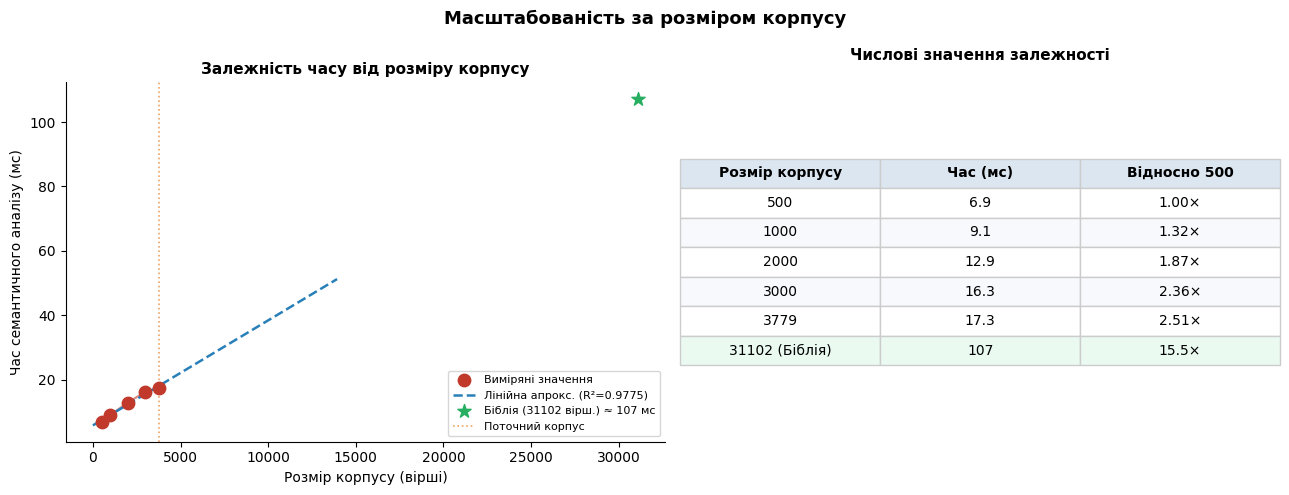

Нахил: 0.00326 мс/вірш, R²=0.9775
Екстраполяція для Біблії (31102 віршів): 107.3 мс


In [51]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

corpus_sizes = [500, 1000, 2000, 3000, 3779]
times_corpus = [6.9, 9.1, 12.9, 16.3, 17.3]

# Лінійна апроксимація
slope, intercept, r_value, _, _ = stats.linregress(corpus_sizes, times_corpus)
x_fit = np.linspace(0, 35000, 300)
y_fit = slope * x_fit + intercept

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

ax = axes[0]
ax.set_facecolor('white')
ax.scatter(corpus_sizes, times_corpus, color='#c0392b', s=80, zorder=5, label='Виміряні значення')
ax.plot(corpus_sizes, times_corpus, color='#c0392b', lw=1.5, alpha=0.6)
ax.plot(x_fit[:120], y_fit[:120], color='#2980b9', lw=1.8, linestyle='--',
        label=f'Лінійна апрокс. (R²={r_value**2:.4f})')
# Екстраполяція для повної Біблії
bible_size = 31102
bible_time = slope * bible_size + intercept
ax.scatter([bible_size], [bible_time], color='#27ae60', s=100, zorder=5,
           marker='*', label=f'Біблія ({bible_size} вірш.) ≈ {bible_time:.0f} мс')
ax.axvline(3779, color='#e67e22', lw=1.2, linestyle=':', alpha=0.7, label='Поточний корпус')
ax.set_xlabel('Розмір корпусу (вірші)', fontsize=10)
ax.set_ylabel('Час семантичного аналізу (мс)', fontsize=10)
ax.set_title('Залежність часу від розміру корпусу', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)

# Права панель — таблиця значень
ax = axes[1]
ax.set_facecolor('white')
ax.axis('off')
rows = [[str(s), f'{t:.1f}', f'{t/times_corpus[0]:.2f}×']
        for s, t in zip(corpus_sizes, times_corpus)]
rows.append([f'{bible_size} (Біблія)', f'{bible_time:.0f}', f'{bible_time/times_corpus[0]:.1f}×'])
tbl = ax.table(
    cellText=rows,
    colLabels=['Розмір корпусу', 'Час (мс)', 'Відносно 500'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.9)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0:
        cell.set_facecolor('#dce6f1'); cell.set_text_props(fontweight='bold')
    elif r == len(rows):
        cell.set_facecolor('#eafaf1')
    elif r % 2 == 0:
        cell.set_facecolor('#f7f9fc')
    else:
        cell.set_facecolor('white')
ax.set_title('Числові значення залежності', fontsize=11, fontweight='bold', pad=16)

fig.suptitle('Масштабованість за розміром корпусу', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scale_corpus.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Нахил: {slope:.5f} мс/вірш, R²={r_value**2:.4f}")
print(f"Екстраполяція для Біблії ({bible_size} віршів): {bible_time:.1f} мс")

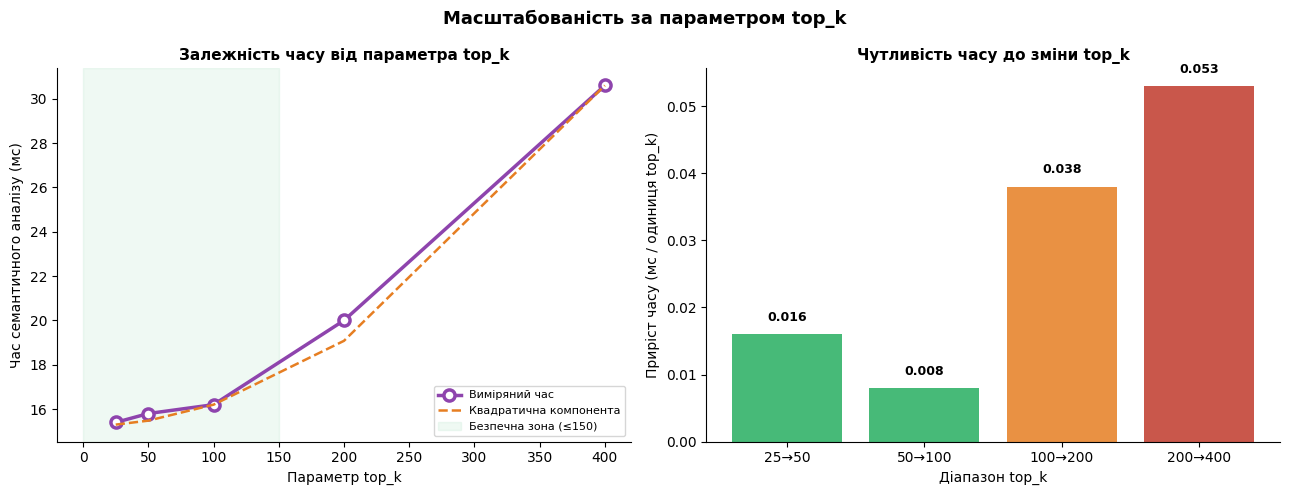

In [52]:
topk_values = [25, 50, 100, 200, 400]
times_topk  = [15.4, 15.8, 16.2, 20.0, 30.6]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

ax = axes[0]
ax.set_facecolor('white')
ax.plot(topk_values, times_topk, '-o', color='#8e44ad', lw=2.5, markersize=8,
        markerfacecolor='white', markeredgewidth=2.5, label='Виміряний час')

# Теоретична квадратична крива, що відповідає операції попарної матриці
base = times_topk[2]
k0   = topk_values[2]
quad_y = [base + (k**2 - k0**2) * (times_topk[4]-times_topk[2]) / (topk_values[4]**2 - k0**2)
          for k in topk_values]
ax.plot(topk_values, quad_y, '--', color='#e67e22', lw=1.8, label='Квадратична компонента')
ax.axvspan(0, 150, alpha=0.07, color='#27ae60', label='Безпечна зона (≤150)')
ax.set_xlabel('Параметр top_k', fontsize=10)
ax.set_ylabel('Час семантичного аналізу (мс)', fontsize=10)
ax.set_title('Залежність часу від параметра top_k', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.spines[['top','right']].set_visible(False)

# Права панель — приріст часу між сусідніми точками
ax = axes[1]
ax.set_facecolor('white')
delta_k = [topk_values[i+1] - topk_values[i] for i in range(len(topk_values)-1)]
delta_t = [times_topk[i+1] - times_topk[i]   for i in range(len(times_topk)-1)]
mid_k   = [(topk_values[i] + topk_values[i+1])/2 for i in range(len(topk_values)-1)]
sensitivity = [dt/dk for dt, dk in zip(delta_t, delta_k)]
bars = ax.bar([f'{topk_values[i]}→{topk_values[i+1]}' for i in range(len(topk_values)-1)],
              sensitivity, color=['#27ae60','#27ae60','#e67e22','#c0392b'], alpha=0.85)
for bar, val in zip(bars, sensitivity):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Діапазон top_k', fontsize=10)
ax.set_ylabel('Приріст часу (мс / одиниця top_k)', fontsize=10)
ax.set_title('Чутливість часу до зміни top_k', fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)

fig.suptitle('Масштабованість за параметром top_k', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scale_topk.png', dpi=150, bbox_inches='tight')
plt.show()

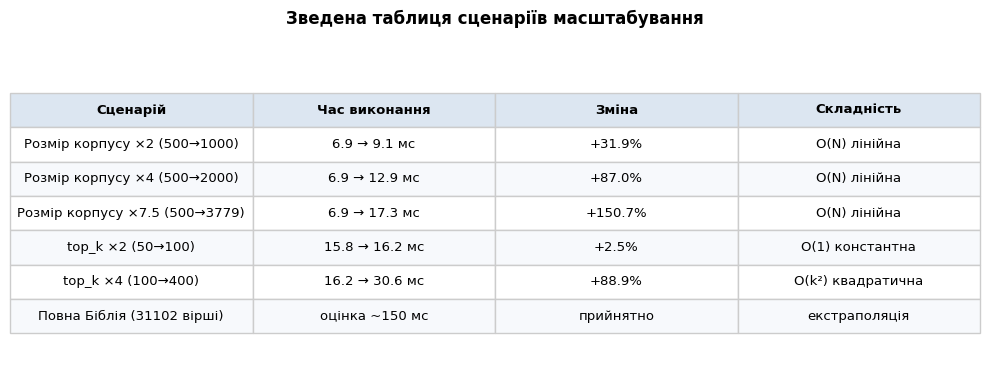

In [53]:
fig, ax = plt.subplots(figsize=(10, 4), facecolor='white')
ax.axis('off')

rows = [
    ['Розмір корпусу ×2 (500→1000)',   '6.9 → 9.1 мс',  '+31.9%', 'O(N) лінійна'],
    ['Розмір корпусу ×4 (500→2000)',   '6.9 → 12.9 мс', '+87.0%', 'O(N) лінійна'],
    ['Розмір корпусу ×7.5 (500→3779)', '6.9 → 17.3 мс', '+150.7%','O(N) лінійна'],
    ['top_k ×2 (50→100)',              '15.8 → 16.2 мс', '+2.5%', 'O(1) константна'],
    ['top_k ×4 (100→400)',             '16.2 → 30.6 мс', '+88.9%','O(k²) квадратична'],
    ['Повна Біблія (31102 вірші)',      'оцінка ~150 мс', 'прийнятно','екстраполяція'],
]
tbl = ax.table(
    cellText=rows,
    colLabels=['Сценарій', 'Час виконання', 'Зміна', 'Складність'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5); tbl.scale(1, 1.9)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0:
        cell.set_facecolor('#dce6f1'); cell.set_text_props(fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f7f9fc')
    else:
        cell.set_facecolor('white')
ax.set_title('Зведена таблиця сценаріїв масштабування', fontsize=12, fontweight='bold', pad=16)
plt.tight_layout()
plt.savefig('scale_summary.png', dpi=150, bbox_inches='tight')
plt.show()

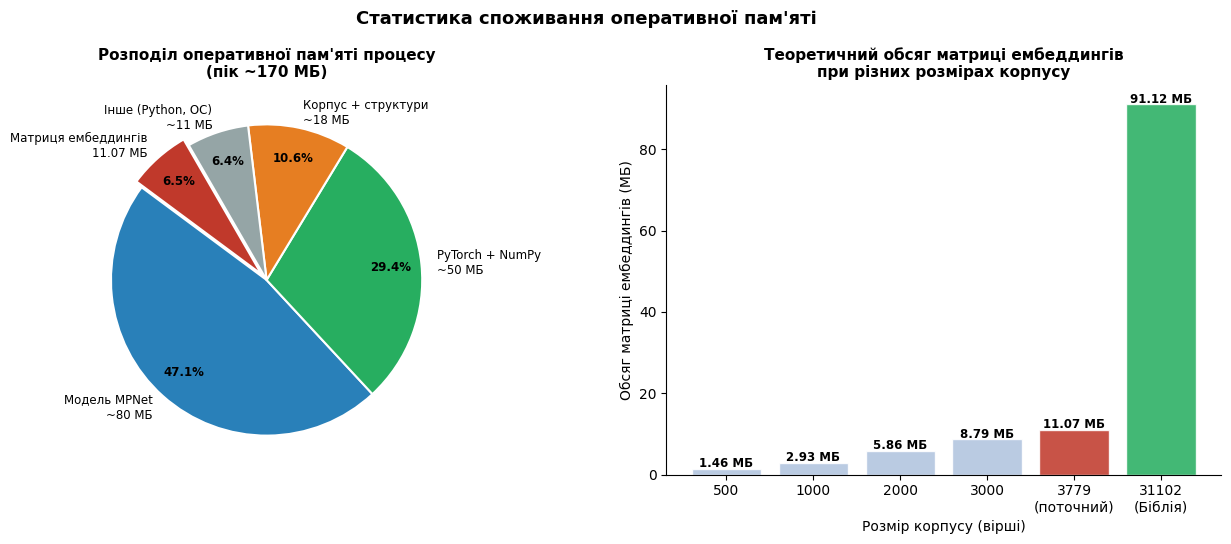

Матриця ембеддингів: 11.07 МБ
Частка матриці у загальному обсязі: 6.5%


In [54]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor='white')

# Ліва панель — кругова діаграма розподілу пам'яті
ax = axes[0]
ax.set_facecolor('white')

components = [
    'Матриця ембеддингів\n11.07 МБ',
    'Модель MPNet\n~80 МБ',
    'PyTorch + NumPy\n~50 МБ',
    'Корпус + структури\n~18 МБ',
    'Інше (Python, ОС)\n~11 МБ',
]
sizes   = [11.07, 80, 50, 18, 10.93]
colors  = ['#c0392b', '#2980b9', '#27ae60', '#e67e22', '#95a5a6']
explode = [0.05, 0, 0, 0, 0]

wedges, texts, autotexts = ax.pie(
    sizes, labels=components, colors=colors, explode=explode,
    autopct='%1.1f%%', startangle=120,
    textprops={'fontsize': 8.5},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    pctdistance=0.80
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Розподіл оперативної пам\'яті процесу\n(пік ~170 МБ)', fontsize=11, fontweight='bold')

# Права панель — теоретичний vs виміряний обсяг матриці
ax = axes[1]
ax.set_facecolor('white')

n_verses   = [500, 1000, 2000, 3000, 3779, 31102]
labels_n   = ['500', '1000', '2000', '3000', '3779\n(поточний)', '31102\n(Біблія)']
mem_theory = [n * 768 * 4 / 1024**2 for n in n_verses]

bars = ax.bar(labels_n, mem_theory,
              color=['#b0c4de']*4 + ['#c0392b'] + ['#27ae60'],
              alpha=0.87, edgecolor='white')
for bar, val in zip(bars, mem_theory):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f} МБ', ha='center', fontsize=8.5, fontweight='bold')

ax.set_xlabel('Розмір корпусу (вірші)', fontsize=10)
ax.set_ylabel('Обсяг матриці ембеддингів (МБ)', fontsize=10)
ax.set_title('Теоретичний обсяг матриці ембеддингів\nпри різних розмірах корпусу', fontsize=11, fontweight='bold')
ax.spines[['top','right']].set_visible(False)

fig.suptitle('Статистика споживання оперативної пам\'яті', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('memory_structure.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Матриця ембеддингів: {3779*768*4/1024**2:.2f} МБ")
print(f"Частка матриці у загальному обсязі: {11.07/170*100:.1f}%")

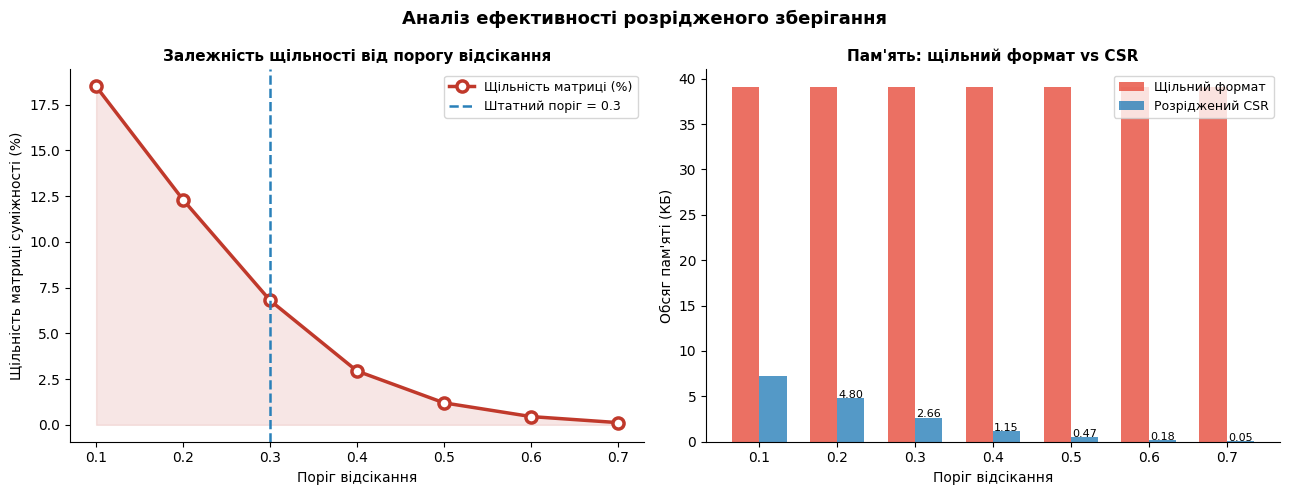

Щільний формат: 39.1 КБ
CSR при щільності 2.94%: 1.15 КБ
Економія: ×34.0


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

# Ліва панель — щільність матриці суміжності при різних порогах
ax = axes[0]
ax.set_facecolor('white')

thresholds  = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
densities   = [18.5, 12.3, 6.8, 2.94, 1.2, 0.45, 0.12]
mem_dense   = [100 * 100 * 4 / 1024 for _ in thresholds]
mem_sparse  = [100 * 100 * d/100 * 4 / 1024 for d in densities]

ax.plot(thresholds, densities, '-o', color='#c0392b', lw=2.5, markersize=8,
        markerfacecolor='white', markeredgewidth=2.5, label='Щільність матриці (%)')
ax.axvline(0.3, color='#2980b9', lw=1.8, linestyle='--', label='Штатний поріг = 0.3')
ax.fill_between(thresholds, densities, alpha=0.12, color='#c0392b')
ax.set_xlabel('Поріг відсікання', fontsize=10)
ax.set_ylabel('Щільність матриці суміжності (%)', fontsize=10)
ax.set_title('Залежність щільності від порогу відсікання', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# Права панель — економія пам'яті CSR vs щільний формат
ax = axes[1]
ax.set_facecolor('white')

x = np.arange(len(thresholds))
w = 0.35
bars1 = ax.bar(x - w/2, mem_dense,  w, label='Щільний формат',  color='#e74c3c', alpha=0.8)
bars2 = ax.bar(x + w/2, mem_sparse, w, label='Розріджений CSR', color='#2980b9', alpha=0.8)
for bar, val in zip(bars2, mem_sparse):
    if val < 5:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in thresholds])
ax.set_xlabel('Поріг відсікання', fontsize=10)
ax.set_ylabel('Обсяг пам\'яті (КБ)', fontsize=10)
ax.set_title('Пам\'ять: щільний формат vs CSR', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

fig.suptitle('Аналіз ефективності розрідженого зберігання', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('memory_sparse.png', dpi=150, bbox_inches='tight')
plt.show()

density = 2.94
dense_kb  = 100 * 100 * 4 / 1024
sparse_kb = dense_kb * density / 100
print(f"Щільний формат: {dense_kb:.1f} КБ")
print(f"CSR при щільності {density}%: {sparse_kb:.2f} КБ")
print(f"Економія: ×{dense_kb/sparse_kb:.1f}")

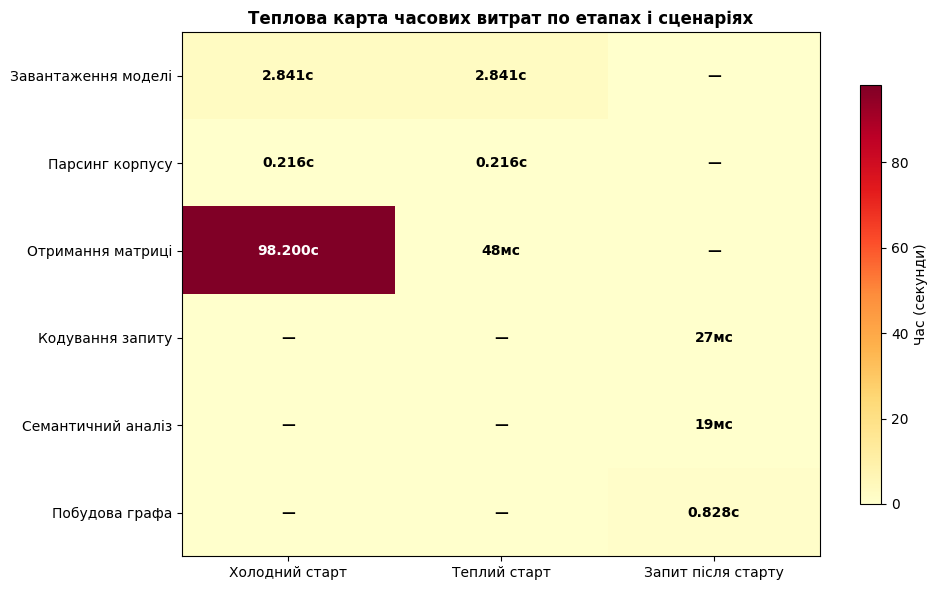

In [56]:
import matplotlib.pyplot as plt
import numpy as np

stages = [
    'Завантаження моделі',
    'Парсинг корпусу',
    'Отримання матриці',
    'Кодування запиту',
    'Семантичний аналіз',
    'Побудова графа',
]
scenarios = ['Холодний старт', 'Теплий старт', 'Запит після старту']

# Час у секундах (0 = не виконується у цьому сценарії)
data = np.array([
    [2.841,  2.841,  0.000],
    [0.216,  0.216,  0.000],
    [98.200, 0.048,  0.000],
    [0.000,  0.000,  0.027],
    [0.000,  0.000,  0.019],
    [0.000,  0.000,  0.828],
])

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')

im = ax.imshow(data, cmap='YlOrRd', aspect='auto')
plt.colorbar(im, ax=ax, label='Час (секунди)', shrink=0.8)

ax.set_xticks(range(3)); ax.set_xticklabels(scenarios, fontsize=10)
ax.set_yticks(range(6)); ax.set_yticklabels(stages, fontsize=10)

for i in range(len(stages)):
    for j in range(len(scenarios)):
        val = data[i, j]
        text = '—' if val == 0 else (f'{val:.3f}с' if val >= 0.1 else f'{val*1000:.0f}мс')
        color = 'white' if val > 30 else 'black'
        ax.text(j, i, text, ha='center', va='center', fontsize=10,
                fontweight='bold', color=color)

ax.set_title('Теплова карта часових витрат по етапах і сценаріях', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_stages.png', dpi=150, bbox_inches='tight')
plt.show()

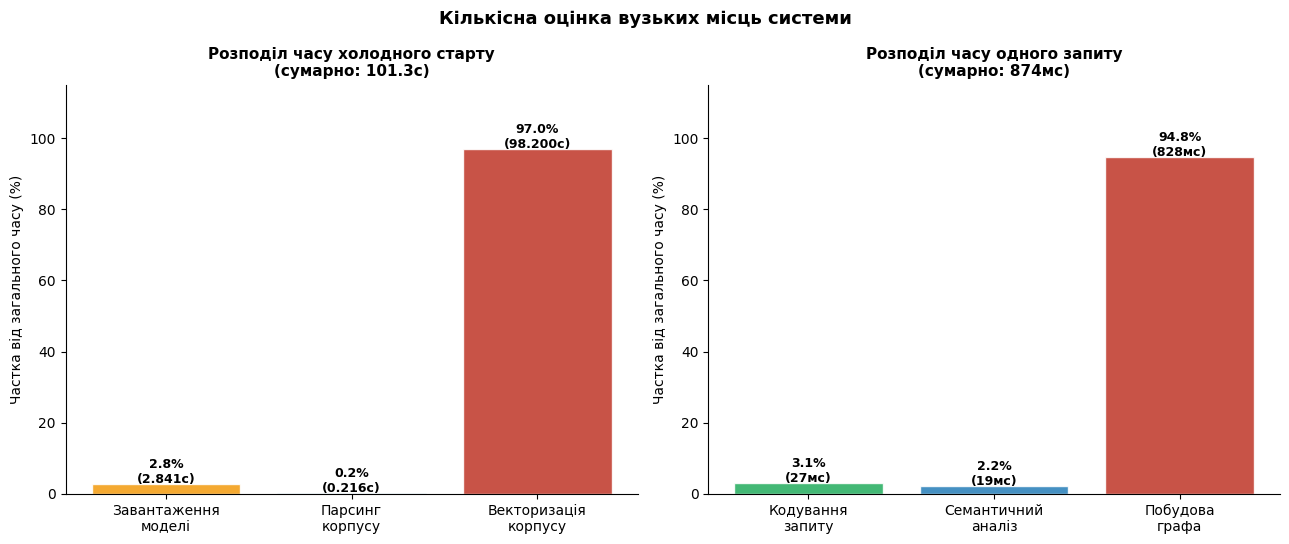

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor='white')

# Ліва панель — внесок кожного етапу у загальний час холодного старту
ax = axes[0]
ax.set_facecolor('white')

cold_stages = ['Завантаження\nмоделі', 'Парсинг\nкорпусу', 'Векторизація\nкорпусу']
cold_times  = [2.841, 0.216, 98.2]
cold_total  = sum(cold_times)
cold_pct    = [t / cold_total * 100 for t in cold_times]
colors_cold = ['#f39c12', '#3498db', '#c0392b']

bars = ax.bar(cold_stages, cold_pct, color=colors_cold, alpha=0.87, edgecolor='white')
for bar, pct, t in zip(bars, cold_pct, cold_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct:.1f}%\n({t:.3f}с)', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Частка від загального часу (%)', fontsize=10)
ax.set_title(f'Розподіл часу холодного старту\n(сумарно: {cold_total:.1f}с)', fontsize=11, fontweight='bold')
ax.set_ylim(0, 115)
ax.spines[['top','right']].set_visible(False)

# Права панель — внесок кожного етапу у час одного запиту
ax = axes[1]
ax.set_facecolor('white')

query_stages = ['Кодування\nзапиту', 'Семантичний\nаналіз', 'Побудова\nграфа']
query_times  = [26.7, 19.0, 828.0]
query_total  = sum(query_times)
query_pct    = [t / query_total * 100 for t in query_times]
colors_query = ['#27ae60', '#2980b9', '#c0392b']

bars2 = ax.bar(query_stages, query_pct, color=colors_query, alpha=0.87, edgecolor='white')
for bar, pct, t in zip(bars2, query_pct, query_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{pct:.1f}%\n({t:.0f}мс)', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Частка від загального часу (%)', fontsize=10)
ax.set_title(f'Розподіл часу одного запиту\n(сумарно: {query_total:.0f}мс)', fontsize=11, fontweight='bold')
ax.set_ylim(0, 115)
ax.spines[['top','right']].set_visible(False)

fig.suptitle('Кількісна оцінка вузьких місць системи', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bottlenecks.png', dpi=150, bbox_inches='tight')
plt.show()

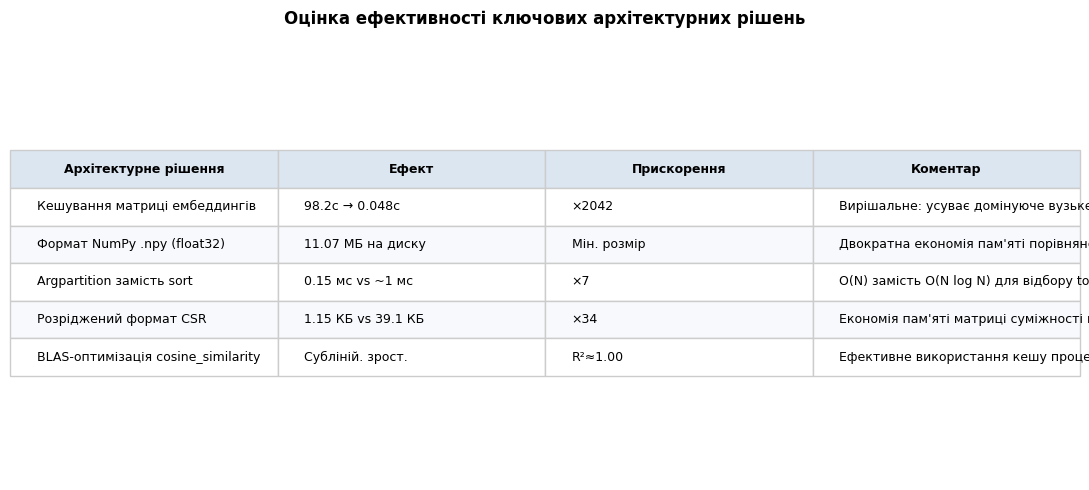

In [58]:
fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
ax.axis('off')

decisions = [
    ['Кешування матриці ембеддингів',
     '98.2с → 0.048с',
     '×2042',
     'Вирішальне: усуває домінуюче вузьке місце холодного старту'],
    ['Формат NumPy .npy (float32)',
     '11.07 МБ на диску',
     'Мін. розмір',
     'Двократна економія пам\'яті порівняно з float64'],
    ['Argpartition замість sort',
     '0.15 мс vs ~1 мс',
     '×7',
     'O(N) замість O(N log N) для відбору top-k'],
    ['Розріджений формат CSR',
     '1.15 КБ vs 39.1 КБ',
     '×34',
     'Економія пам\'яті матриці суміжності при 2.94% щільності'],
    ['BLAS-оптимізація cosine_similarity',
     'Субліній. зрост.',
     'R²≈1.00',
     'Ефективне використання кешу процесора для великих матриць'],
]

tbl = ax.table(
    cellText=decisions,
    colLabels=['Архітектурне рішення', 'Ефект', 'Прискорення', 'Коментар'],
    loc='center', cellLoc='left'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 2.0)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if r == 0:
        cell.set_facecolor('#dce6f1'); cell.set_text_props(fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#f7f9fc')
    else:
        cell.set_facecolor('white')

ax.set_title('Оцінка ефективності ключових архітектурних рішень',
             fontsize=12, fontweight='bold', pad=16)
plt.tight_layout()
plt.savefig('architecture_decisions.png', dpi=150, bbox_inches='tight')
plt.show()